# 📊 GARCH · COPULA · PORTFOLIO CONSTRUCTION
**Multi-Horizon Risk Modelling Pipeline**

| Section | Description |
|---|---|
| 0 | Install & Import Dependencies |
| 1 | Upload Data Files |
| 2 | Load & Compute Returns |
| 3 | Multi-Horizon Returns |
| 4–5 | GARCH Volatility Filtering |
| 6 | Macro GARCH + Copula Modelling |
| 7 | Horizon-Level Copula Correlations |
| 8–9 | Stock-Level GARCH + Feature Engineering |
| 10–11 | ML Models + K-Means Clustering |
| 12–13 | Portfolio Construction + Horizon Performance |
| 14–15 | Monte Carlo VaR/ES + Transaction Cost Sensitivity |
| 16 | Export All Results |

---
**Expected input files** (upload in Section 1):
```
streamlined_s&p_500.csv
streamlined_euro_stoxx_50.csv
streamlined_ftse_100.csv
streamlined_ibovespa.csv
streamlined_jse_top_40.csv
streamlined_nikkei_225.csv
streamlined_asx_50.csv
streamlined_macro.csv
```

## Section 0 — Install & Import Dependencies
> ⏱️ **Run once per session.** Colab resets installations when runtime disconnects.

In [ ]:
# ── Install packages not pre-installed on Colab ───────────────────────────────
import subprocess, sys

PACKAGES = [
    'arch',
    'copulas',
    'xgboost',
    'umap-learn',
]

for pkg in PACKAGES:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n✅ All packages installed')

Installing arch...
Installing copulas...
Installing xgboost...
Installing umap-learn...

✅ All packages installed


In [ ]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from itertools import combinations

from scipy import stats
from scipy.stats import kendalltau
from scipy.special import gammaln
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import t as t_dist, rankdata
from numpy.linalg import inv, slogdet

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split

import xgboost as xgb
from xgboost import XGBRegressor
from arch import arch_model
from copulas.multivariate import GaussianMultivariate

try:
    import umap
    UMAP_OK = True
    print('UMAP available ✅')
except ImportError:
    from sklearn.manifold import TSNE
    UMAP_OK = False
    print('UMAP not found — using t-SNE instead')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9', 'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 11,
})

# ── Global constants ──────────────────────────────────────────────────────────
ASIAN_MARKETS   = {'ASX50', 'Nikkei225'}
DAILY_HORIZONS  = [1, 2, 3, 4, 5]
WEEKLY_HORIZONS = [1, 2, 3, 4]
RF              = 0.02 / 252   # daily risk-free rate (2% p.a.)

PRICE_COLS = ['ASX50','EUROSTOXX50','FTSE100','Ibovespa','NIKKEI225','SP500',
              'AUDUSD','BRLUSD','EURUSD','GBPUSD','JPYUSD','ZARUSD',
              'Gold','Oil','Bitcoin','VIX']
RATE_COLS  = ['US_10Y','DE_10Y','UK_10Y','JP_10Y','AU_10Y','ZA_10Y']

MACRO_INDEX_MAP = {
    'SP500':       'SP500',
    'EuroStoxx50': 'EUROSTOXX50',
    'FTSE100':     'FTSE100',
    'Ibovespa':    'Ibovespa',
    'JSE40':       None,
    'Nikkei225':   'NIKKEI225',
    'ASX50':       'ASX50',
}

MACRO_IDX_MAP = {
    'ASX50': 'ASX50', 'EuroStoxx50': 'EUROSTOXX50', 'FTSE100': 'FTSE100',
    'Ibovespa': 'Ibovespa', 'JSE40': 'JSE40', 'Nikkei225': 'NIKKEI225', 'SP500': 'SP500',
}

print('\n✅ All imports successful')

UMAP available ✅

✅ All imports successful


---
## Section 1 — Upload Data Files
> Upload all 8 CSV files using the widget below. You can upload them all at once.

In [ ]:
from google.colab import files
import io

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION A — Upload directly from your computer
# Select all 8 CSV files at once using the file picker below.
# ═══════════════════════════════════════════════════════════════════════════════

EXPECTED_FILES = [
    'streamlined_s&p_500.csv',
    'streamlined_euro_stoxx_50.csv',
    'streamlined_ftse_100.csv',
    'streamlined_ibovespa.csv',
    'streamlined_jse_top_40.csv',
    'streamlined_nikkei_225.csv',
    'streamlined_asx_50.csv',
    'streamlined_macro.csv',
]

print('📁 Select ALL 8 CSV files at once (hold Ctrl/Cmd to multi-select):')
for f in EXPECTED_FILES:
    print(f'   · {f}')
print()

uploaded = files.upload()

# Save every uploaded file to /content/
for fname, content in uploaded.items():
    with open(f'/content/{fname}', 'wb') as fh:
        fh.write(content)
    size_kb = len(content) / 1024
    print(f'  ✅ Saved: {fname}  ({size_kb:.1f} KB)')

DATA_DIR = Path('/content')

# ── Validation check ─────────────────────────────────────────────────────────
print('\n── Upload Validation ────────────────────────────────────────')
found     = {p.name for p in DATA_DIR.glob('*.csv')}
all_ok    = True
for fname in EXPECTED_FILES:
    if fname in found:
        print(f'  ✅ {fname}')
    else:
        print(f'  ❌ MISSING: {fname}')
        all_ok = False
if all_ok:
    print('\n🎉 All 8 files uploaded and ready!')
else:
    print('\n⚠️  Some files are missing — re-run this cell and upload the missing files.')

📁 Select ALL 8 CSV files at once (hold Ctrl/Cmd to multi-select):
   · streamlined_s&p_500.csv
   · streamlined_euro_stoxx_50.csv
   · streamlined_ftse_100.csv
   · streamlined_ibovespa.csv
   · streamlined_jse_top_40.csv
   · streamlined_nikkei_225.csv
   · streamlined_asx_50.csv
   · streamlined_macro.csv



Saving streamlined_asx_50.csv to streamlined_asx_50.csv
Saving streamlined_euro_stoxx_50.csv to streamlined_euro_stoxx_50.csv
Saving streamlined_ftse_100.csv to streamlined_ftse_100.csv
Saving streamlined_ibovespa.csv to streamlined_ibovespa.csv
Saving streamlined_jse_top_40.csv to streamlined_jse_top_40.csv
Saving streamlined_macro.csv to streamlined_macro.csv
Saving streamlined_nikkei_225.csv to streamlined_nikkei_225.csv
Saving streamlined_s&p_500.csv to streamlined_s&p_500.csv
  ✅ Saved: streamlined_asx_50.csv  (1927.4 KB)
  ✅ Saved: streamlined_euro_stoxx_50.csv  (1995.0 KB)
  ✅ Saved: streamlined_ftse_100.csv  (3727.4 KB)
  ✅ Saved: streamlined_ibovespa.csv  (2438.4 KB)
  ✅ Saved: streamlined_jse_top_40.csv  (1146.6 KB)
  ✅ Saved: streamlined_macro.csv  (772.2 KB)
  ✅ Saved: streamlined_nikkei_225.csv  (8890.1 KB)
  ✅ Saved: streamlined_s&p_500.csv  (19734.4 KB)

── Upload Validation ────────────────────────────────────────
  ✅ streamlined_s&p_500.csv
  ✅ streamlined_euro_stoxx_5

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPTION B — Load from Google Drive (skip if you used Option A above)
# Mount your Drive, then copy your files into /content/
# ═══════════════════════════════════════════════════════════════════════════════

# from google.colab import drive
# drive.mount('/content/drive')

# DRIVE_FOLDER = '/content/drive/My Drive/YOUR_FOLDER_NAME'  # ← edit this
# import shutil
# for fname in EXPECTED_FILES:
#     src = f'{DRIVE_FOLDER}/{fname}'
#     dst = f'/content/{fname}'
#     if os.path.exists(src):
#         shutil.copy(src, dst)
#         print(f'  ✅ Copied from Drive: {fname}')
#     else:
#         print(f'  ❌ Not found in Drive: {src}')

# DATA_DIR = Path('/content')
print('ℹ️  Option B is commented out. Uncomment the lines above if you want to load from Google Drive.')


In [ ]:
# ── File loader with fuzzy matching ──────────────────────────────────────────
MARKET_FILES = {
    'SP500':       'streamlined_s&p_500.csv',
    'EuroStoxx50': 'streamlined_euro_stoxx_50.csv',
    'FTSE100':     'streamlined_ftse_100.csv',
    'Ibovespa':    'streamlined_ibovespa.csv',
    'JSE40':       'streamlined_jse_top_40.csv',
    'Nikkei225':   'streamlined_nikkei_225.csv',
    'ASX50':       'streamlined_asx_50.csv',
}
MACRO_FILE = 'streamlined_macro.csv'

def load_csv(fname, data_dir=DATA_DIR):
    candidates = {p.name: p for p in data_dir.glob('*.csv')}
    if fname in candidates:
        path = candidates[fname]
    else:
        def norm(s):
            return re.sub(r'\s*\(\d+\)$', '', s.replace('.csv','').lower()).replace('&','_').replace(' ','_')
        target = norm(fname)
        path = next((p for n, p in candidates.items() if norm(n) == target), None)
        if path is None:
            raise FileNotFoundError(f"Cannot find '{fname}' in {data_dir.resolve()}")
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    return df

print('Verifying uploaded files...')
for mkt, fname in MARKET_FILES.items():
    try:
        df = load_csv(fname)
        print(f'  ✅ {mkt:15s} → {df.shape}')
    except FileNotFoundError as e:
        print(f'  ❌ {e}')

try:
    df_macro_check = load_csv(MACRO_FILE)
    print(f'  ✅ Macro          → {df_macro_check.shape}')
except FileNotFoundError as e:
    print(f'  ❌ {e}')

Verifying uploaded files...
  ✅ SP500           → (2413, 460)
  ✅ EuroStoxx50     → (2413, 46)
  ✅ FTSE100         → (2413, 90)
  ✅ Ibovespa        → (2413, 56)
  ✅ JSE40           → (2413, 31)
  ✅ Nikkei225       → (2413, 217)
  ✅ ASX50           → (2413, 44)
  ✅ Macro          → (2413, 22)


---
## Section 2 — Load Data & Compute Log Returns

In [ ]:
# ── Load price data ───────────────────────────────────────────────────────────
print('Loading price data...')
prices = {}
for mkt, fname in MARKET_FILES.items():
    try:
        prices[mkt] = load_csv(fname)
        print(f'  {mkt:15s} → {prices[mkt].shape}')
    except FileNotFoundError as e:
        print(f'  ⚠ {e}')

print('\nLoading macro data...')
try:
    macro_raw = load_csv(MACRO_FILE)
    print(f'  Macro → {macro_raw.shape}')
except FileNotFoundError as e:
    print(f'  ⚠ {e}')
    macro_raw = pd.DataFrame()

# ── Stock-level log returns ───────────────────────────────────────────────────
def compute_log_returns(df, ffill_limit=5, min_nonnan=0.70):
    lr = np.log(df / df.shift(1)).iloc[1:]
    lr = lr.ffill(limit=ffill_limit)
    lr = lr.loc[:, lr.notna().mean() >= min_nonnan]
    return lr

stock_returns = {mkt: compute_log_returns(df) for mkt, df in prices.items()}
print('\n✅ Stock-level log returns computed')
for mkt, sr in stock_returns.items():
    print(f'   {mkt:15s} → {sr.shape}')

Loading price data...
  SP500           → (2413, 460)
  EuroStoxx50     → (2413, 46)
  FTSE100         → (2413, 90)
  Ibovespa        → (2413, 56)
  JSE40           → (2413, 31)
  Nikkei225       → (2413, 217)
  ASX50           → (2413, 44)

Loading macro data...
  Macro → (2413, 22)

✅ Stock-level log returns computed
   SP500           → (2412, 460)
   EuroStoxx50     → (2412, 46)
   FTSE100         → (2412, 90)
   Ibovespa        → (2412, 56)
   JSE40           → (2412, 31)
   Nikkei225       → (2412, 217)
   ASX50           → (2412, 44)


In [ ]:
# ── Macro returns ─────────────────────────────────────────────────────────────
macro_ret = pd.DataFrame(index=macro_raw.index)
for c in PRICE_COLS:
    if c in macro_raw.columns:
        macro_ret[c] = np.log(macro_raw[c] / macro_raw[c].shift(1))
for c in RATE_COLS:
    if c in macro_raw.columns:
        macro_ret[c] = macro_raw[c].diff()
macro_ret = macro_ret.iloc[1:].ffill(limit=5)

# JSE40 proxy
jse_px  = prices['JSE40'].ffill(limit=5)
jse_idx = jse_px.mean(axis=1)
macro_ret['JSE40'] = np.log(jse_idx / jse_idx.shift(1))

# ── Index-level daily returns ─────────────────────────────────────────────────
idx_daily = pd.DataFrame()
for mkt, col in MACRO_INDEX_MAP.items():
    col_name = col if col else mkt
    s = macro_ret[col_name].dropna().copy()
    if mkt in ASIAN_MARKETS:
        s = s.shift(1)
    idx_daily[mkt] = s
idx_daily = idx_daily.dropna()

EQUITY_COLS = list(idx_daily.columns)
print(f'Index daily returns: {idx_daily.shape[0]} dates '
      f'({idx_daily.index[0].date()} – {idx_daily.index[-1].date()})')
print(f'Markets: {EQUITY_COLS}')
idx_daily.tail(3)

Index daily returns: 2411 dates (2015-01-07 – 2025-12-30)
Markets: ['SP500', 'EuroStoxx50', 'FTSE100', 'Ibovespa', 'JSE40', 'Nikkei225', 'ASX50']


,SP500,EuroStoxx50,FTSE100,Ibovespa,JSE40,Nikkei225,ASX50
2025-12-23,0.004540,0.000973,0.002349,0.014526,0.005009,0.017920,0.009197
2025-12-29,-0.000586,0.000423,-0.002298,0.000212,-0.000308,0.000208,0.010554
2025-12-30,-0.001377,0.007709,0.007492,0.003949,0.001617,0.002260,-0.007083


---
## Section 3 — Multi-Horizon Returns (D1–D5, W1–W4)

In [ ]:
horizon_returns = {}

for d in DAILY_HORIZONS:
    label = f'D{d}'
    horizon_returns[label] = idx_daily.copy() if d == 1 else idx_daily.rolling(d).sum().dropna()

for w in WEEKLY_HORIZONS:
    label = f'W{w}'
    horizon_returns[label] = idx_daily.rolling(w * 5).sum().dropna()

all_labels = [f'D{d}' for d in DAILY_HORIZONS] + [f'W{w}' for w in WEEKLY_HORIZONS]

print('Horizon return shapes:')
for h, df in horizon_returns.items():
    print(f'  {h}: {df.shape}')

Horizon return shapes:
  D1: (2411, 7)
  D2: (2410, 7)
  D3: (2409, 7)
  D4: (2408, 7)
  D5: (2407, 7)
  W1: (2407, 7)
  W2: (2402, 7)
  W3: (2397, 7)
  W4: (2392, 7)


---
## Section 4 — GARCH(1,1) Function Definition

In [ ]:
def fit_garch(series, dist='skewt'):
    """
    Fit GARCH(1,1) with skewed-t innovations (fallback: normal).
    Returns: cond_vol, std_resid, pit_u, params dict, index
    """
    s     = series.dropna()
    scale = 100.0
    am    = arch_model(s * scale, vol='Garch', p=1, q=1, dist=dist, rescale=False)
    try:
        res = am.fit(disp='off', show_warning=False, options={'maxiter': 500})
    except Exception:
        am  = arch_model(s * scale, vol='Garch', p=1, q=1, dist='normal', rescale=False)
        res = am.fit(disp='off', show_warning=False)

    cond_vol  = res.conditional_volatility / scale
    std_resid = res.resid / res.conditional_volatility
    n         = len(std_resid)
    pit_u     = rankdata(std_resid) / (n + 1)

    params = {
        'omega':       res.params.get('omega',    np.nan),
        'alpha':       res.params.get('alpha[1]', np.nan),
        'beta':        res.params.get('beta[1]',  np.nan),
        'persistence': res.params.get('alpha[1]', 0) + res.params.get('beta[1]', 0),
        'aic':         res.aic,
    }
    return cond_vol, std_resid, pit_u, params, s.index

print('✅ GARCH function defined')

✅ GARCH function defined


---
## Section 5 — GARCH on Index-Level Returns (All Horizons)

In [ ]:
print('Fitting GARCH on index-level daily returns...')
print('='*60)

garch_index = {}
pit_series  = {}
vol_series  = {}

for mkt in idx_daily.columns:
    s = idx_daily[mkt].dropna()
    cond_vol, std_resid, pit_u, params, idx = fit_garch(s)
    garch_index[mkt] = {
        'cond_vol':  pd.Series(cond_vol,  index=idx),
        'std_resid': pd.Series(std_resid, index=idx),
        'pit':       pd.Series(pit_u,     index=idx, name=mkt),
        'params':    params,
    }
    pit_series[mkt] = pd.Series(pit_u,    index=idx, name=mkt)
    vol_series[mkt] = pd.Series(cond_vol, index=idx, name=mkt)
    print(f'  {mkt:15s}  α+β={params["persistence"]:.4f}  AIC={params["aic"]:.2f}')

pit_df = pd.concat(pit_series, axis=1).dropna()
vol_df = pd.concat(vol_series, axis=1).dropna()

# Parameter table
garch_params_idx = pd.DataFrame(
    {mkt: garch_index[mkt]['params'] for mkt in garch_index}
).T
print('\n── GARCH Index Parameters ──')
display(garch_params_idx.round(6))

Fitting GARCH on index-level daily returns...
  SP500            α+β=0.9922  AIC=6229.57
  EuroStoxx50      α+β=0.9663  AIC=7084.63
  FTSE100          α+β=0.9431  AIC=6031.22
  Ibovespa         α+β=0.9752  AIC=8172.32
  JSE40            α+β=0.9263  AIC=6938.07
  Nikkei225        α+β=0.9242  AIC=7724.25
  ASX50            α+β=0.9632  AIC=5837.18

── GARCH Index Parameters ──


,omega,alpha,beta,persistence,aic
SP500,0.024925,0.179899,0.812274,0.992173,6229.569057
EuroStoxx50,0.067397,0.155040,0.811302,0.966342,7084.625365
FTSE100,0.059066,0.163341,0.779735,0.943076,6031.223683
Ibovespa,0.048558,0.070277,0.904954,0.975230,8172.324260
JSE40,0.090593,0.125150,0.801141,0.926291,6938.068308
Nikkei225,0.152870,0.165375,0.758831,0.924206,7724.253286
ASX50,0.032310,0.116877,0.846366,0.963243,5837.178470


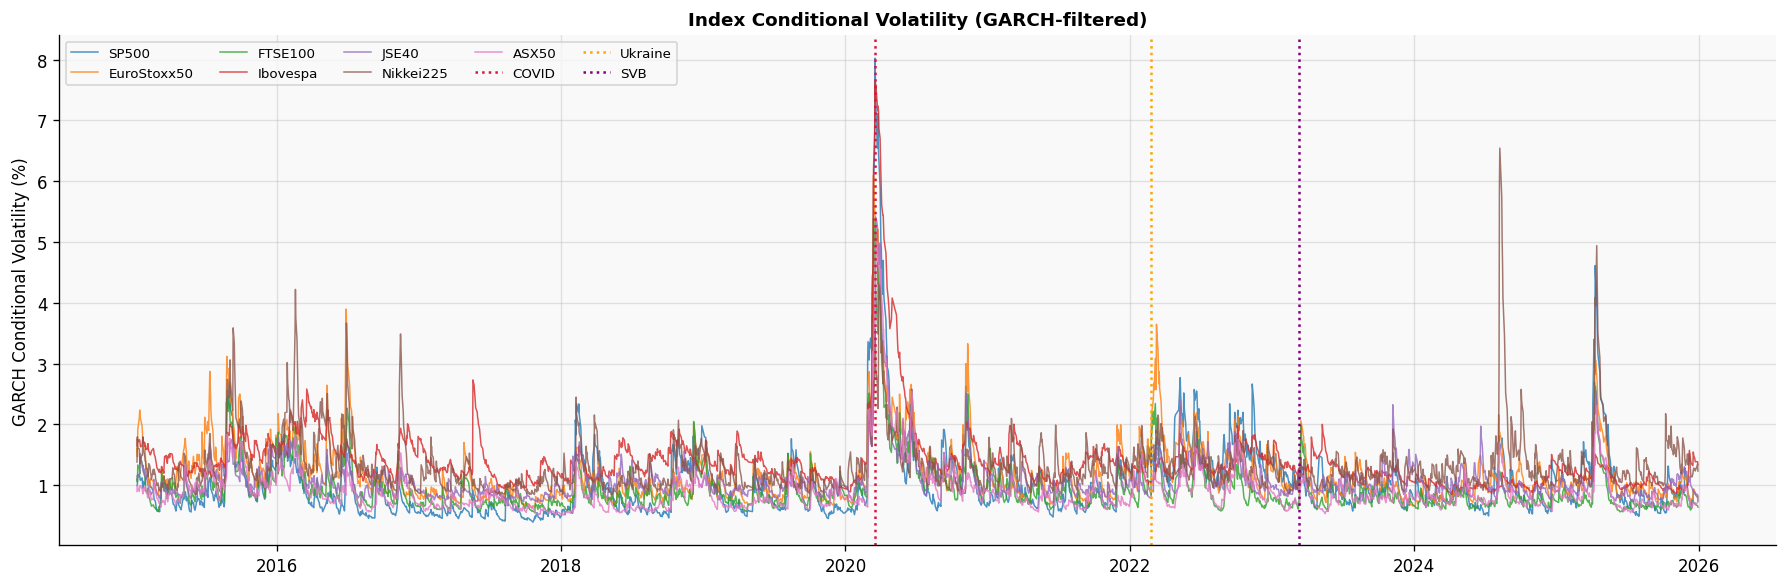

✅ Index-level GARCH complete


In [ ]:
# ── Conditional Volatility Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
for mkt in vol_df.columns:
    ax.plot(vol_df.index, vol_df[mkt]*100, lw=0.9, alpha=0.8, label=mkt)
for ts, lbl, c in [('2020-03-16','COVID','crimson'),
                   ('2022-02-24','Ukraine','orange'),
                   ('2023-03-10','SVB','purple')]:
    if pd.Timestamp(ts) in vol_df.index or (vol_df.index[0] <= pd.Timestamp(ts) <= vol_df.index[-1]):
        ax.axvline(pd.Timestamp(ts), color=c, ls=':', lw=1.5, label=lbl)
ax.set_ylabel('GARCH Conditional Volatility (%)')
ax.set_title('Index Conditional Volatility (GARCH-filtered)', fontweight='bold')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig('garch_vol.png', bbox_inches='tight', dpi=130)
plt.show()
print('✅ Index-level GARCH complete')

---
## Section 6 — Macro GARCH Filtering + Copula Modelling

In [ ]:
MACRO_COPULA_MAP = {
    'VIX':    'VIX',    'Oil':    'Oil',    'Gold':   'Gold',
    'EURUSD': 'EURUSD', 'JPYUSD': 'JPYUSD',
    'BRLUSD': 'BRLUSD', 'ZARUSD': 'ZARUSD',
    'US_10Y': 'US_10Y', 'DE_10Y': 'DE_10Y',
}

macro_pit = {mkt: garch_index[mkt]['pit'] for mkt in idx_daily.columns}

print('Fitting GARCH on macro factors...')
for var_name, col in MACRO_COPULA_MAP.items():
    if col not in macro_ret.columns:
        print(f'  {var_name}: NOT FOUND — skipping'); continue
    try:
        _, _, pit_u, params, idx = fit_garch(macro_ret[col].dropna(), dist='skewt')
        macro_pit[var_name] = pd.Series(pit_u, index=idx, name=var_name)
        print(f'  {var_name:12s}  α+β={params["persistence"]:.4f}  AIC={params["aic"]:.2f}')
    except Exception as e:
        print(f'  {var_name}: FAILED ({e})')

full_pit_df = pd.concat(macro_pit, axis=1).dropna()
print(f'\n✅ Full PIT matrix: {full_pit_df.shape[0]} dates × {full_pit_df.shape[1]} variables')

Fitting GARCH on macro factors...
  VIX           α+β=0.9009  AIC=16338.45
  Oil           α+β=0.9634  AIC=10939.59
  Gold          α+β=0.9925  AIC=6556.01
  EURUSD        α+β=0.9927  AIC=3419.50
  JPYUSD        α+β=0.9850  AIC=3940.63
  BRLUSD        α+β=0.9835  AIC=7027.97
  ZARUSD        α+β=0.8964  AIC=6919.85
  US_10Y        α+β=0.9913  AIC=14785.69
  DE_10Y        α+β=0.1262  AIC=3606.39

✅ Full PIT matrix: 2411 dates × 16 variables


In [ ]:
# ── Gaussian Copula ───────────────────────────────────────────────────────────
gc_full = GaussianMultivariate()
gc_full.fit(full_pit_df)
gaussian_corr_full = gc_full.correlation.copy()
gaussian_corr_full.index = gaussian_corr_full.columns = full_pit_df.columns
gaussian_corr = gaussian_corr_full.loc[EQUITY_COLS, EQUITY_COLS]
print('✅ Gaussian copula fitted')

# ── t-Copula ──────────────────────────────────────────────────────────────────
def t_copula_loglik(nu, U, R):
    d, T = U.shape[1], U.shape[0]
    X    = t_dist.ppf(np.clip(U, 1e-6, 1-1e-6), df=nu)
    eigv = np.linalg.eigvalsh(R)
    if eigv.min() < 1e-8:
        R = R + np.eye(d) * (1e-8 - eigv.min())
        D = np.diag(1 / np.sqrt(np.diag(R))); R = D @ R @ D
    Rinv = inv(R); sign, logdetR = slogdet(R)
    if sign <= 0: return 1e10
    quad  = np.einsum('ti,ij,tj->t', X, Rinv, X)
    joint = (gammaln((nu+d)/2) - gammaln(nu/2) - 0.5*logdetR
             - (d/2)*np.log(nu*np.pi) - ((nu+d)/2)*np.log(1 + quad/nu))
    marg  = (gammaln((nu+1)/2) - gammaln(nu/2) - 0.5*np.log(nu*np.pi)
             - ((nu+1)/2)*np.log(1 + X**2/nu)).sum(axis=1)
    return -(joint - marg).sum()

def t_tail_dep(rho, nu):
    return 2 * t_dist.sf(np.sqrt((nu+1)*(1-rho)/(1+rho)), df=nu+1)

R_full = gaussian_corr_full.values.copy(); np.fill_diagonal(R_full, 1.0)
U_full = full_pit_df.values

print('Optimising t-copula ν (this may take a moment)...')
nu_grid  = np.arange(2.5, 30.1, 0.5)
nll_grid = [t_copula_loglik(nu, U_full, R_full) for nu in nu_grid]
best_nu  = nu_grid[np.argmin(nll_grid)]
result   = minimize_scalar(
    lambda nu: t_copula_loglik(nu, U_full, R_full),
    bounds=(max(2.1, best_nu-2), min(30., best_nu+2)),
    method='bounded', options={'xatol': 0.05}
)
nu_hat = result.x
tail_lbl = 'heavy' if nu_hat < 8 else 'moderate' if nu_hat < 15 else 'near-Gaussian'
print(f'✅ t-Copula ν = {nu_hat:.2f} ({tail_lbl} tails)')

mean_eq_corr = gaussian_corr.values[np.triu_indices(len(EQUITY_COLS), k=1)].mean()
lambda_U     = t_tail_dep(mean_eq_corr, nu_hat)
print(f'   Mean equity ρ = {mean_eq_corr:.3f}  →  λ_U = {lambda_U:.4f}')

✅ Gaussian copula fitted
Optimising t-copula ν (this may take a moment)...
✅ t-Copula ν = 16.20 (near-Gaussian tails)
   Mean equity ρ = 0.240  →  λ_U = 0.0047


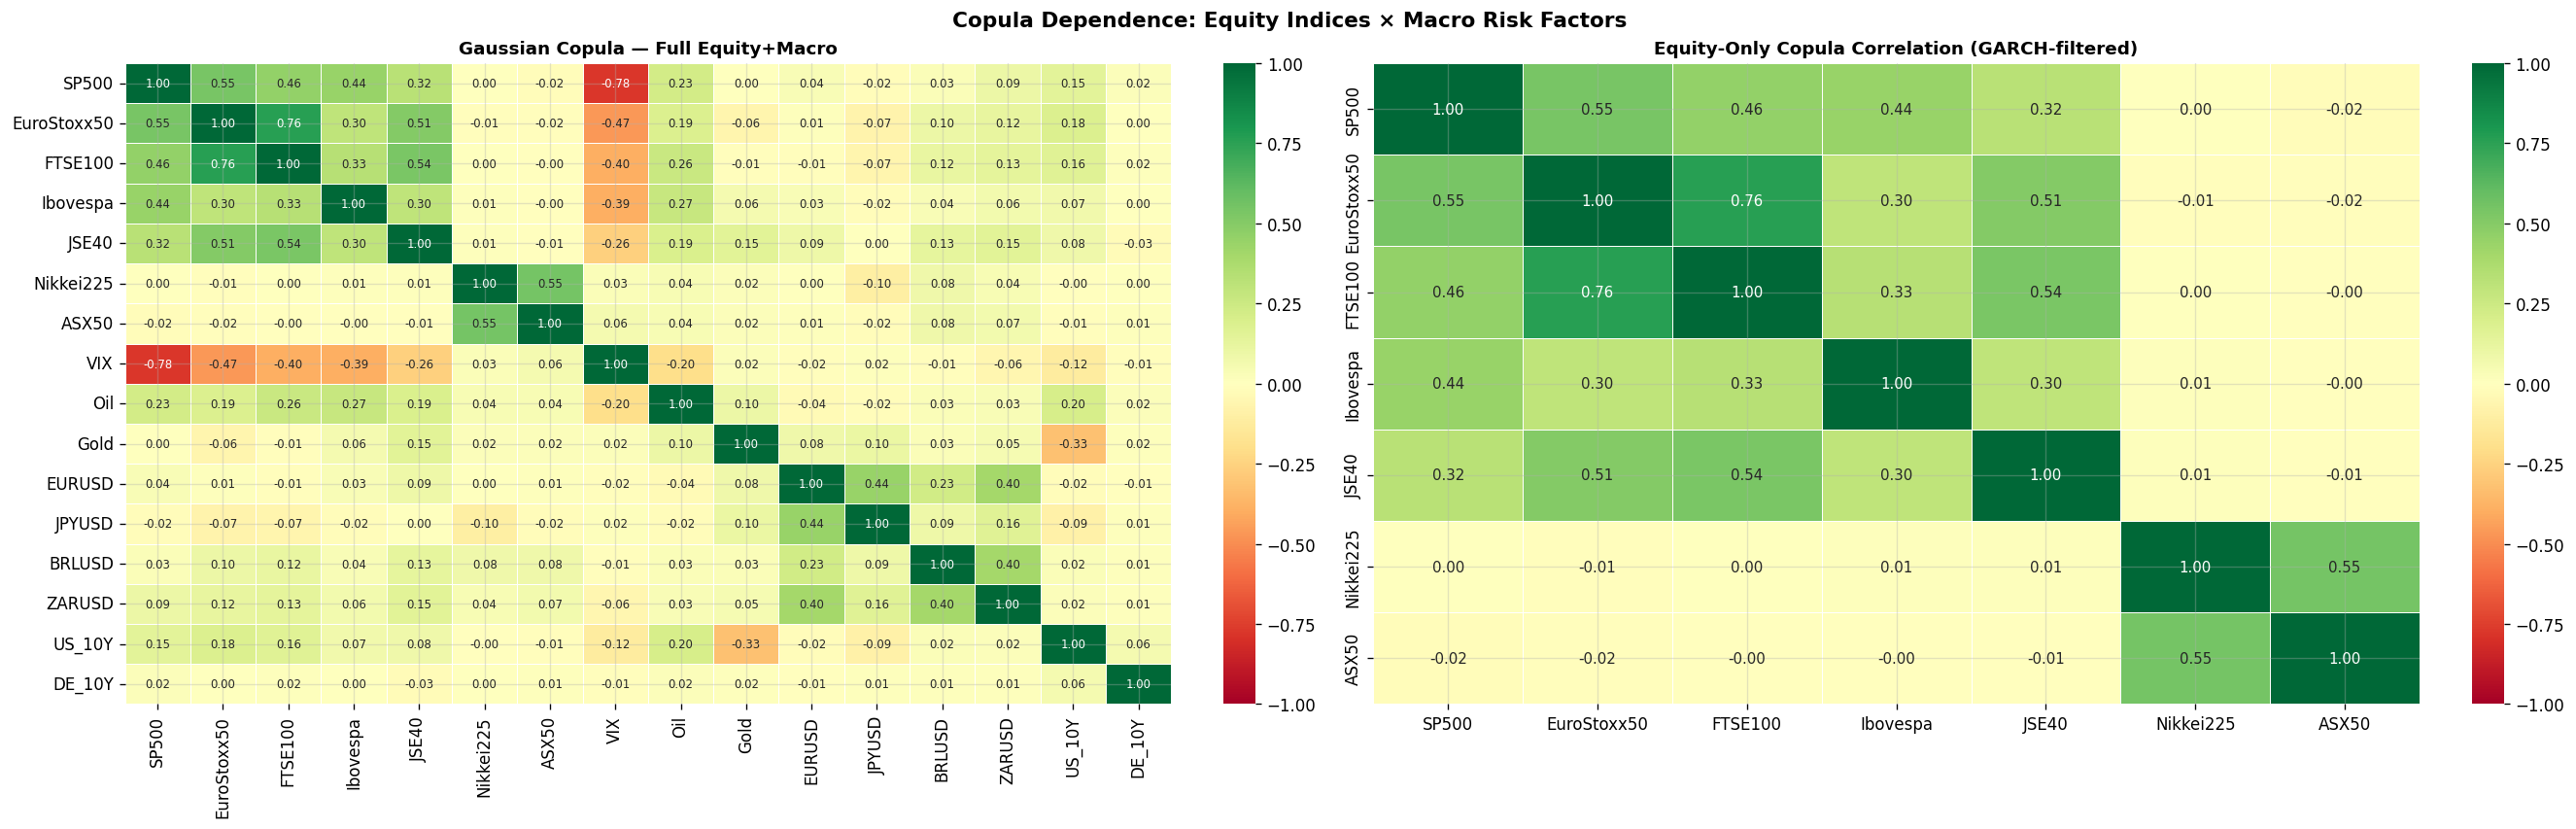

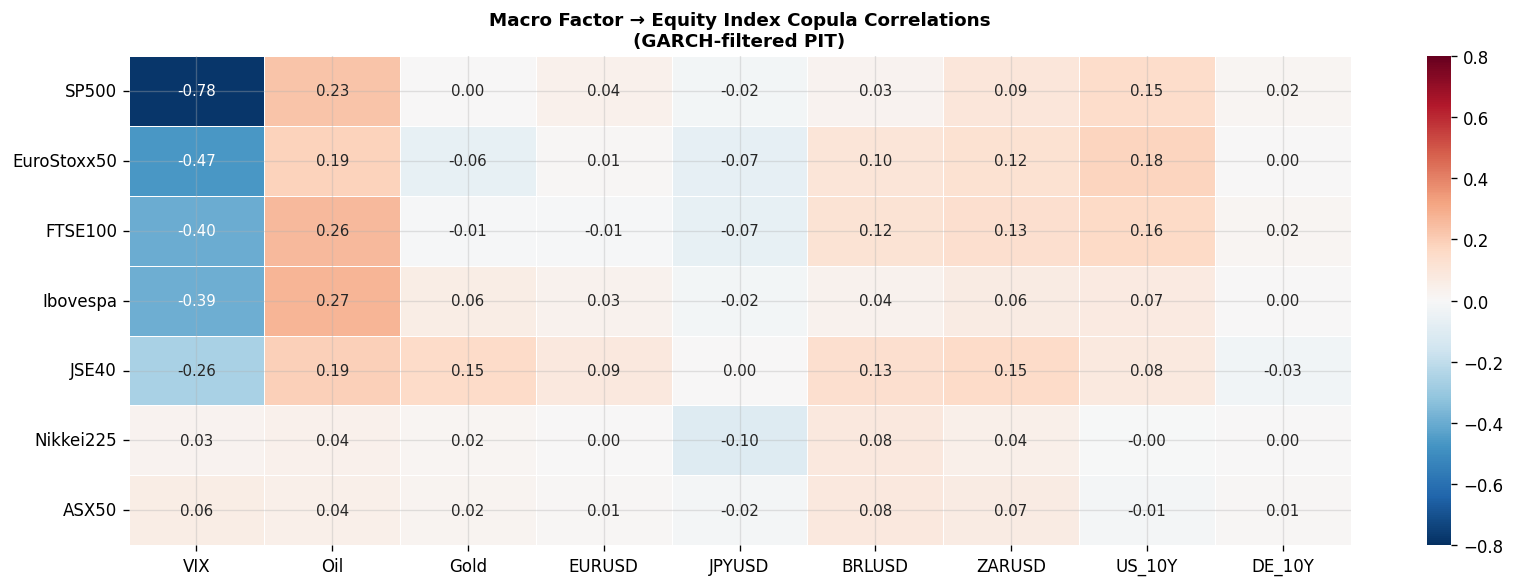

✅ Copula modelling complete


In [ ]:
# ── Copula Heatmaps ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)
sns.heatmap(gaussian_corr_full, ax=axes[0], cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.4,
            annot_kws={'size': 7})
axes[0].set_title('Gaussian Copula — Full Equity+Macro', fontweight='bold')
sns.heatmap(gaussian_corr, ax=axes[1], cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.4,
            annot_kws={'size': 9})
axes[1].set_title('Equity-Only Copula Correlation (GARCH-filtered)', fontweight='bold')
fig.suptitle('Copula Dependence: Equity Indices × Macro Risk Factors', fontsize=13, fontweight='bold')
plt.savefig('copula_full_macro.png', bbox_inches='tight'); plt.show()

# Macro → Equity heatmap
macro_factors = [c for c in full_pit_df.columns if c not in EQUITY_COLS]
macro_eq_corr = gaussian_corr_full.loc[EQUITY_COLS, macro_factors]
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(macro_eq_corr, ax=ax, cmap='RdBu_r', center=0,
            vmin=-0.8, vmax=0.8, annot=True, fmt='.2f', linewidths=0.4,
            annot_kws={'size': 9})
ax.set_title('Macro Factor → Equity Index Copula Correlations\n(GARCH-filtered PIT)', fontweight='bold')
plt.tight_layout(); plt.savefig('macro_equity_copula.png', bbox_inches='tight'); plt.show()
print('✅ Copula modelling complete')

---
## Section 7 — Horizon-Level Copula Correlations (D1–D5, W1–W4)

In [ ]:
def horizon_pit(ret_series):
    s = ret_series.dropna()
    return pd.Series(rankdata(s) / (len(s) + 1), index=s.index, name=ret_series.name)

horizon_copula_corr = {}

for h_label, ret_df in horizon_returns.items():
    pit_h = pd.concat(
        [horizon_pit(ret_df[mkt]) for mkt in EQUITY_COLS], axis=1
    ).dropna()
    X_h   = stats.norm.ppf(np.clip(pit_h.values, 1e-4, 1-1e-4))
    corr_h = pd.DataFrame(np.corrcoef(X_h.T), index=EQUITY_COLS, columns=EQUITY_COLS)
    horizon_copula_corr[h_label] = corr_h
    mean_r = corr_h.values[np.triu_indices(len(EQUITY_COLS), k=1)].mean()
    print(f'  {h_label}: mean pairwise copula ρ = {mean_r:.4f}')

  D1: mean pairwise copula ρ = 0.2521
  D2: mean pairwise copula ρ = 0.3527
  D3: mean pairwise copula ρ = 0.4252
  D4: mean pairwise copula ρ = 0.4642
  D5: mean pairwise copula ρ = 0.4868
  W1: mean pairwise copula ρ = 0.4868
  W2: mean pairwise copula ρ = 0.5313
  W3: mean pairwise copula ρ = 0.5438
  W4: mean pairwise copula ρ = 0.5473


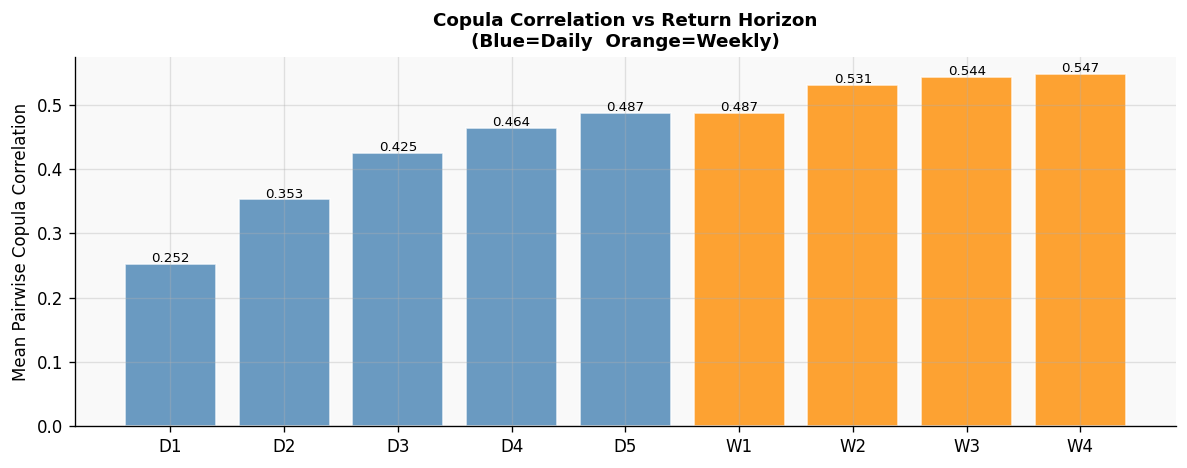

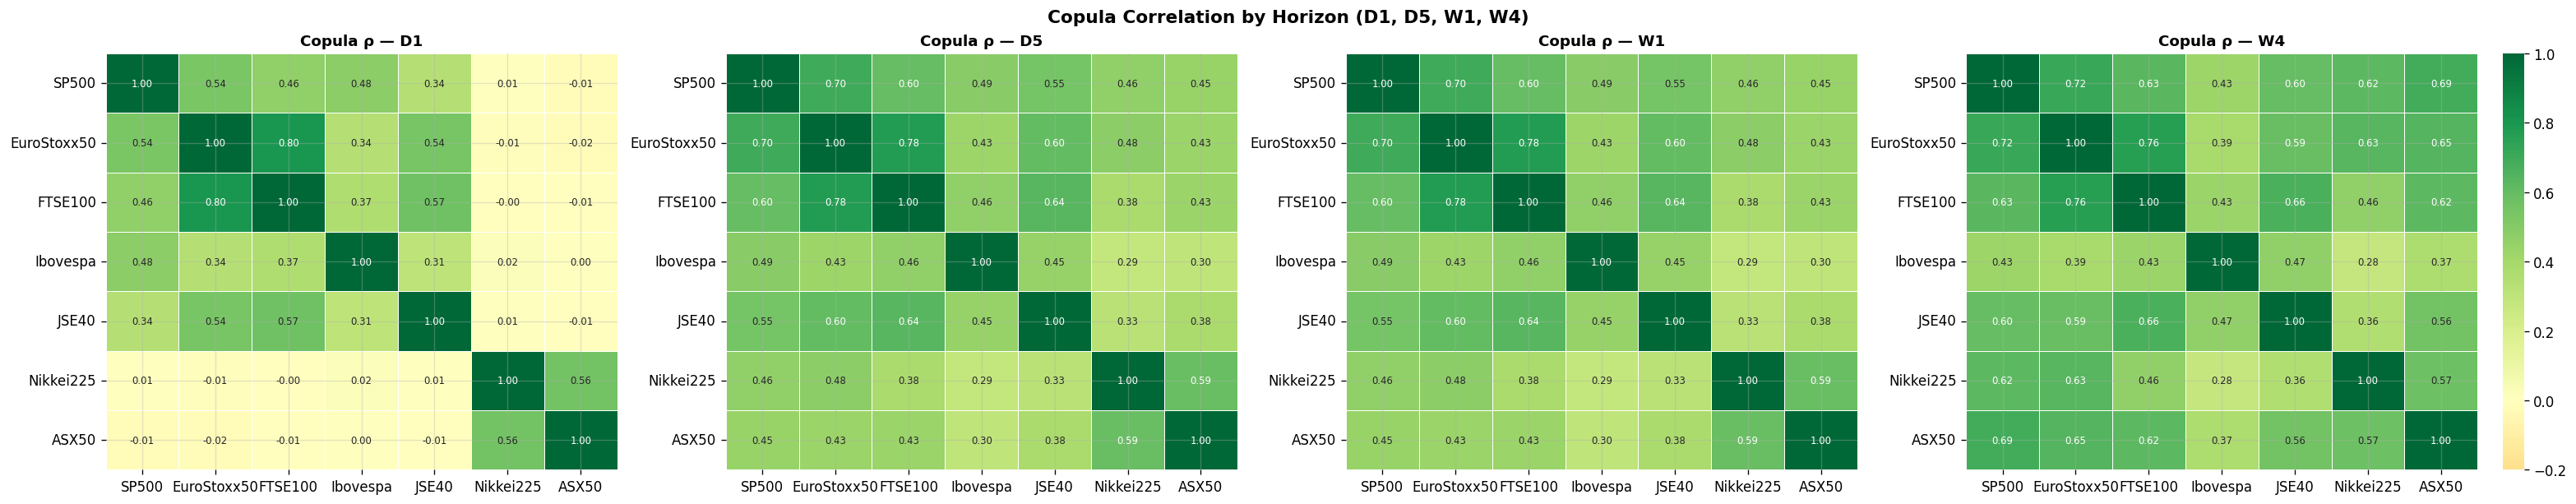

✅ Horizon copula analysis complete


In [ ]:
# ── Mean copula correlation vs horizon bar chart ───────────────────────────────
mean_corrs = [horizon_copula_corr[h].values[
                np.triu_indices(len(EQUITY_COLS), k=1)].mean()
              for h in all_labels]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue']*len(DAILY_HORIZONS) + ['darkorange']*len(WEEKLY_HORIZONS)
ax.bar(all_labels, mean_corrs, color=colors, alpha=0.8, edgecolor='white')
ax.set_ylabel('Mean Pairwise Copula Correlation')
ax.set_title('Copula Correlation vs Return Horizon\n(Blue=Daily  Orange=Weekly)', fontweight='bold')
for i, (lbl, val) in enumerate(zip(all_labels, mean_corrs)):
    ax.text(i, val + 0.003, f'{val:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('horizon_copula_corr.png', bbox_inches='tight'); plt.show()

# ── D1, D5, W1, W4 heatmaps ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(26, 5), constrained_layout=True)
for ax, h_lbl in zip(axes, ['D1', 'D5', 'W1', 'W4']):
    sns.heatmap(horizon_copula_corr[h_lbl], ax=ax, cmap='RdYlGn',
                center=0, vmin=-0.2, vmax=1, annot=True, fmt='.2f',
                linewidths=0.4, annot_kws={'size': 7}, cbar=(ax == axes[-1]))
    ax.set_title(f'Copula ρ — {h_lbl}', fontweight='bold')
fig.suptitle('Copula Correlation by Horizon (D1, D5, W1, W4)', fontsize=13, fontweight='bold')
plt.savefig('horizon_copula_heatmaps.png', bbox_inches='tight'); plt.show()
print('✅ Horizon copula analysis complete')

---
## Section 8 — Stock-Level GARCH
> ⏱️ **This section is computationally intensive.** Estimated runtime: 20–50 min on Colab CPU.
>
> 💡 **Tip:** Enable GPU runtime (`Runtime → Change runtime type → T4 GPU`) to speed things up.

In [ ]:
print('='*60)
print('Stock-Level GARCH — this will take a while...')
print('='*60)

garch_results    = {}
index_vol_by_mkt = {}

for market, ret_df in stock_returns.items():
    n_total    = ret_df.shape[1]
    market_res = {}; vols = []
    print(f'\n{market} ({n_total} stocks):', end=' ')
    for i, ticker in enumerate(ret_df.columns):
        s = ret_df[ticker].dropna()
        if len(s) < 250: continue
        try:
            cv, sr, pit, params, idx = fit_garch(s)
            market_res[ticker] = {
                'cond_vol':  pd.Series(cv,  index=idx),
                'std_resid': pd.Series(sr,  index=idx),
                'pit':       pd.Series(pit, index=idx),
                'params':    params,
            }
            vols.append(cv)
        except Exception:
            pass
        if (i+1) % 25 == 0:
            print(f'{i+1}..', end='', flush=True)
    garch_results[market] = market_res
    if vols:
        vdf = pd.concat([pd.Series(v) for v in vols], axis=1)
        index_vol_by_mkt[market] = vdf.mean(axis=1)
    print(f'✓ ({len(market_res)}/{n_total})')

print('\n✅ Stock-level GARCH complete')

Stock-Level GARCH — this will take a while...

SP500 (460 stocks): 25..50..75..100..125..150..175..200..225..250..275..300..325..350..375..400..425..450..✓ (460/460)

EuroStoxx50 (46 stocks): 25..✓ (46/46)

FTSE100 (90 stocks): 25..50..75..✓ (90/90)

Ibovespa (56 stocks): 25..50..✓ (56/56)

JSE40 (31 stocks): 25..✓ (31/31)

Nikkei225 (217 stocks): 25..50..75..100..125..150..175..200..✓ (217/217)

ASX50 (44 stocks): 25..✓ (44/44)

✅ Stock-level GARCH complete


---
## Section 9 — Feature Engineering (25-dim per stock)

In [ ]:
def max_drawdown(ret_series):
    cum = np.exp(ret_series.cumsum())
    return ((cum - cum.cummax()) / cum.cummax()).min()

def rolling_beta(s, bench, window=126):
    cov = s.rolling(window).cov(bench)
    var = bench.rolling(window).var()
    return (cov / var).mean()

MACRO_BETAS = {
    'beta_vix':     macro_ret.get('VIX',     pd.Series(dtype=float)),
    'beta_oil':     macro_ret.get('Oil',     pd.Series(dtype=float)),
    'beta_gold':    macro_ret.get('Gold',    pd.Series(dtype=float)),
    'beta_bitcoin': macro_ret.get('Bitcoin', pd.Series(dtype=float)),
    'beta_eurusd':  macro_ret.get('EURUSD',  pd.Series(dtype=float)),
    'beta_jpyusd':  macro_ret.get('JPYUSD',  pd.Series(dtype=float)),
    'beta_brlusd':  macro_ret.get('BRLUSD',  pd.Series(dtype=float)),
    'beta_zarusd':  macro_ret.get('ZARUSD',  pd.Series(dtype=float)),
    'beta_audusd':  macro_ret.get('AUDUSD',  pd.Series(dtype=float)),
    'beta_us10y':   macro_ret.get('US_10Y',  pd.Series(dtype=float)),
    'beta_de10y':   macro_ret.get('DE_10Y',  pd.Series(dtype=float)),
}

NUMERIC_FEATURES = [
    'garch_alpha', 'garch_beta', 'garch_persistence',
    'ret_mean', 'ret_vol', 'ret_skew', 'ret_kurt',
    'sharpe', 'max_drawdown', 'calmar',
    'vol_mean', 'vol_max', 'vol_covid', 'market_beta',
    'beta_vix', 'beta_oil', 'beta_gold', 'beta_bitcoin',
    'beta_eurusd', 'beta_jpyusd', 'beta_brlusd', 'beta_zarusd', 'beta_audusd',
    'beta_us10y', 'beta_de10y',
]

feature_rows = []
print('Building feature matrix...')

for market, res_dict in garch_results.items():
    mkt_col = MACRO_IDX_MAP.get(market)
    mkt_ret = macro_ret[mkt_col] if mkt_col and mkt_col in macro_ret.columns else None
    for ticker, r in res_dict.items():
        s = stock_returns[market][ticker].dropna()
        if len(s) < 250: continue
        ann_ret = s.mean() * 252
        ann_vol = s.std()  * np.sqrt(252)
        mdd     = max_drawdown(s)
        row = {
            'ticker': ticker, 'market': market,
            'garch_alpha':       r['params']['alpha'],
            'garch_beta':        r['params']['beta'],
            'garch_persistence': r['params']['persistence'],
            'ret_mean':    ann_ret,  'ret_vol':  ann_vol,
            'ret_skew':    s.skew(), 'ret_kurt': s.kurtosis(),
            'sharpe':      ann_ret / ann_vol if ann_vol > 0 else 0,
            'max_drawdown': mdd,
            'calmar':      ann_ret / abs(mdd) if mdd != 0 else 0,
            'vol_mean':    r['cond_vol'].mean(),
            'vol_max':     r['cond_vol'].max(),
            'vol_covid':   r['cond_vol']['2020-02-01':'2020-06-30'].mean(),
            'market_beta': np.nan,
        }
        if mkt_ret is not None:
            cm = s.index.intersection(mkt_ret.index)
            if len(cm) > 126:
                row['market_beta'] = rolling_beta(s.loc[cm], mkt_ret.loc[cm])
        for b_name, b_series in MACRO_BETAS.items():
            if len(b_series) == 0:
                row[b_name] = np.nan; continue
            cm = s.index.intersection(b_series.index)
            row[b_name] = rolling_beta(s.loc[cm], b_series.loc[cm]) if len(cm) > 126 else np.nan
        feature_rows.append(row)

feature_df = pd.DataFrame(feature_rows).set_index('ticker')

X_raw = feature_df[NUMERIC_FEATURES].copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
X_raw = X_raw.clip(lower=X_raw.quantile(0.01), upper=X_raw.quantile(0.99), axis=1)
X_raw = X_raw.fillna(X_raw.median())

print(f'✅ Feature matrix: {X_raw.shape[0]} stocks × {X_raw.shape[1]} features')
print(f'   Markets: {feature_df["market"].value_counts().to_dict()}')

Building feature matrix...
✅ Feature matrix: 944 stocks × 25 features
   Markets: {'SP500': 460, 'Nikkei225': 217, 'FTSE100': 90, 'Ibovespa': 56, 'EuroStoxx50': 46, 'ASX50': 44, 'JSE40': 31}


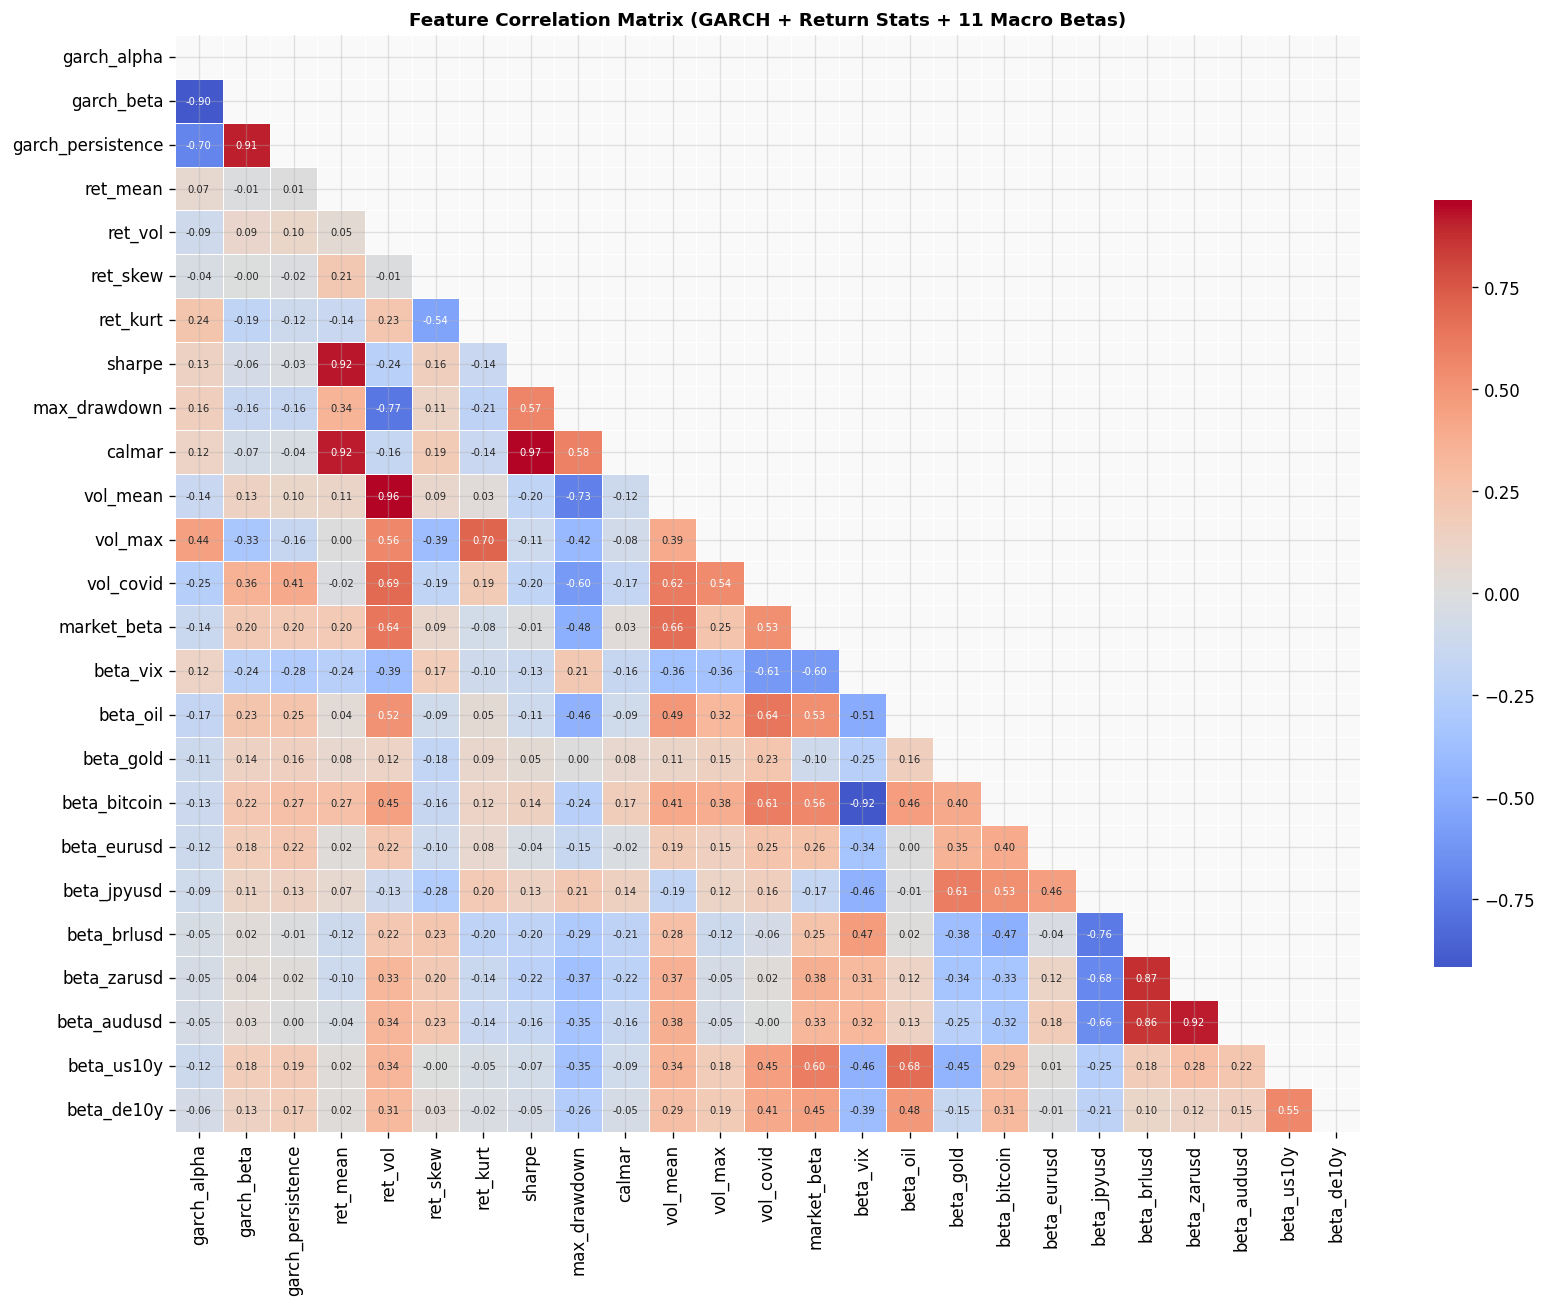

In [ ]:
# ── Feature Correlation Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(X_raw.corr(), dtype=bool))
sns.heatmap(X_raw.corr(), mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            annot_kws={'size': 6}, cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix (GARCH + Return Stats + 11 Macro Betas)', fontweight='bold')
plt.tight_layout(); plt.savefig('feature_correlation.png', bbox_inches='tight'); plt.show()

---
## Section 10 — Machine Learning: Random Forest + XGBoost

In [ ]:
# ── Prepare ML features ───────────────────────────────────────────────────────
XGB_EXCLUDE = ['ret_vol', 'vol_mean', 'vol_max', 'vol_covid', 'garch_alpha']
ml_cols     = [c for c in NUMERIC_FEATURES if c not in XGB_EXCLUDE]
y           = feature_df['sharpe'].values
X_ml        = StandardScaler().fit_transform(X_raw[ml_cols].values)
X_tr, X_te, y_tr, y_te = train_test_split(X_ml, y, test_size=0.2, random_state=42)

print(f'ML feature set: {len(ml_cols)} features, {X_ml.shape[0]} stocks')
print(f'Train/Test split: {len(X_tr)} / {len(X_te)}')

ML feature set: 20 features, 944 stocks
Train/Test split: 755 / 189


[10A] Training XGBoost...
  Train R² = 0.9886  Test R² = 0.9791
  5-fold CV R² = 0.9801 ± 0.0140
  XGBoost leaf PCA(16) embedding: (944, 16)


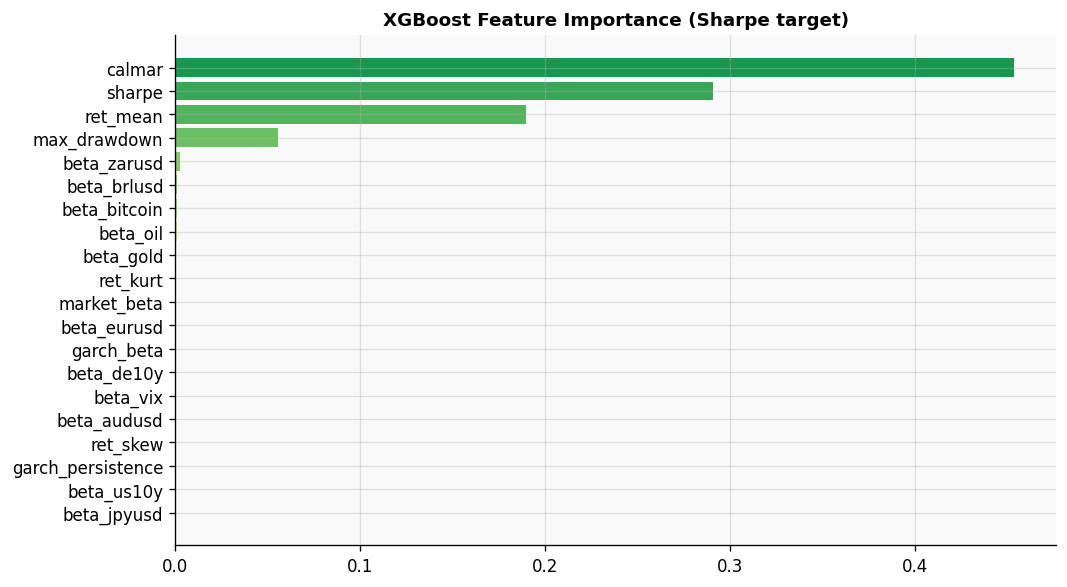

In [ ]:
# ── 10A: XGBoost ──────────────────────────────────────────────────────────────
print('[10A] Training XGBoost...')
xgb_model = XGBRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=5.0,
    min_child_weight=5, random_state=42, verbosity=0
)
xgb_model.fit(X_tr, y_tr)
xgb_train_r2 = xgb_model.score(X_tr, y_tr)
xgb_test_r2  = xgb_model.score(X_te, y_te)
xgb_cv       = cross_val_score(xgb_model, X_ml, y, cv=5, scoring='r2')
print(f'  Train R² = {xgb_train_r2:.4f}  Test R² = {xgb_test_r2:.4f}')
print(f'  5-fold CV R² = {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')
xgb_model.fit(X_ml, y)  # refit on full data

# XGBoost leaf embedding
xgb_leaf     = xgb_model.apply(X_ml)
ohe_xgb      = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
xgb_leaf_ohe = ohe_xgb.fit_transform(xgb_leaf)
pca_xgb_full = PCA(random_state=42).fit(xgb_leaf_ohe)
n_comp_xgb   = min(max(
    np.searchsorted(pca_xgb_full.explained_variance_ratio_.cumsum(), 0.80) + 1, 10), 50)
X_xgb_embed  = PCA(n_components=n_comp_xgb, random_state=42).fit_transform(xgb_leaf_ohe)
X_xgb_sc     = StandardScaler().fit_transform(X_xgb_embed)
print(f'  XGBoost leaf PCA({n_comp_xgb}) embedding: {X_xgb_sc.shape}')

# Feature importance plot
imp_xgb = pd.DataFrame({'feature': ml_cols, 'importance': xgb_model.feature_importances_})
imp_xgb = imp_xgb.sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_xgb['feature'], imp_xgb['importance'],
        color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp_xgb))))
ax.set_title('XGBoost Feature Importance (Sharpe target)', fontweight='bold')
plt.tight_layout(); plt.savefig('xgb_importance.png', bbox_inches='tight'); plt.show()

[10B] Training Random Forest...
  Train R² = 0.9965  Test R² = 0.9902
  5-fold CV R² = 0.9928 ± 0.0063
  RF leaf PCA(50) embedding: (944, 50)


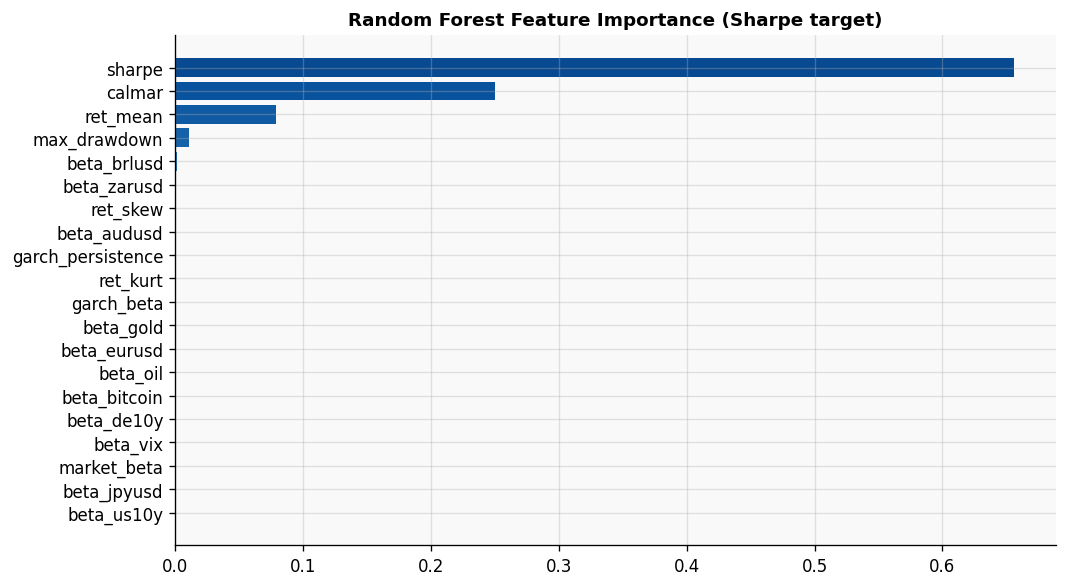


── ML Model Comparison ──


,Train R²,Test R²,CV R² Mean,CV R² Std
XGBoost,0.9886,0.9791,0.9801,0.0140
Random Forest,0.9965,0.9902,0.9928,0.0063


In [ ]:
# ── 10B: Random Forest ────────────────────────────────────────────────────────
print('[10B] Training Random Forest...')
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=5,
    max_features=0.6, random_state=42, n_jobs=-1
)
rf_model.fit(X_tr, y_tr)
rf_train_r2 = rf_model.score(X_tr, y_tr)
rf_test_r2  = rf_model.score(X_te, y_te)
rf_cv       = cross_val_score(rf_model, X_ml, y, cv=5, scoring='r2')
print(f'  Train R² = {rf_train_r2:.4f}  Test R² = {rf_test_r2:.4f}')
print(f'  5-fold CV R² = {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
rf_model.fit(X_ml, y)

# RF leaf embedding
rf_leaves    = rf_model.apply(X_ml)
ohe_rf       = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
rf_leaf_ohe  = ohe_rf.fit_transform(rf_leaves)
pca_rf_full  = PCA(random_state=42).fit(rf_leaf_ohe)
n_comp_rf    = min(max(
    np.searchsorted(pca_rf_full.explained_variance_ratio_.cumsum(), 0.80) + 1, 10), 50)
X_rf_embed   = PCA(n_components=n_comp_rf, random_state=42).fit_transform(rf_leaf_ohe)
X_rf_sc      = StandardScaler().fit_transform(X_rf_embed)
print(f'  RF leaf PCA({n_comp_rf}) embedding: {X_rf_sc.shape}')

# Feature importance plot
imp_rf = pd.DataFrame({'feature': ml_cols, 'importance': rf_model.feature_importances_})
imp_rf = imp_rf.sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_rf['feature'], imp_rf['importance'],
        color=plt.cm.Blues(np.linspace(0.3, 0.9, len(imp_rf))))
ax.set_title('Random Forest Feature Importance (Sharpe target)', fontweight='bold')
plt.tight_layout(); plt.savefig('rf_importance.png', bbox_inches='tight'); plt.show()

# Model comparison table
ml_compare = pd.DataFrame({
    'Train R²':  [xgb_train_r2, rf_train_r2],
    'Test R²':   [xgb_test_r2,  rf_test_r2],
    'CV R² Mean':[xgb_cv.mean(), rf_cv.mean()],
    'CV R² Std': [xgb_cv.std(),  rf_cv.std()],
}, index=['XGBoost', 'Random Forest'])
print('\n── ML Model Comparison ──')
display(ml_compare.round(4))

---
## Section 11 — K-Means Clustering (XGBoost & RF Embeddings)

In [ ]:
K_RANGE = range(4, 14)

def find_optimal_k(X_sc, label=''):
    sil_scores = []
    for k in K_RANGE:
        lbl = KMeans(n_clusters=k, random_state=42, n_init=30).fit_predict(X_sc)
        sil_scores.append(silhouette_score(X_sc, lbl))
    opt_k   = list(K_RANGE)[np.argmax(sil_scores)]
    opt_sil = max(sil_scores)
    print(f'  {label}: Optimal K = {opt_k}  (silhouette = {opt_sil:.4f})')
    km = KMeans(n_clusters=opt_k, random_state=42, n_init=50, max_iter=1000)
    return km.fit_predict(X_sc), opt_k, opt_sil

print('Finding optimal K for XGBoost embedding...')
xgb_clusters, K_xgb, sil_xgb = find_optimal_k(X_xgb_sc, 'XGBoost')
print('Finding optimal K for RF embedding...')
rf_clusters,  K_rf,  sil_rf   = find_optimal_k(X_rf_sc,  'RandomForest')

feature_df['cluster_xgb'] = xgb_clusters
feature_df['cluster_rf']  = rf_clusters

print('\nXGBoost Cluster × Market:')
display(pd.crosstab(feature_df['cluster_xgb'], feature_df['market']))

print('\nRandom Forest Cluster × Market:')
display(pd.crosstab(feature_df['cluster_rf'], feature_df['market']))

Finding optimal K for XGBoost embedding...
  XGBoost: Optimal K = 13  (silhouette = 0.2857)
Finding optimal K for RF embedding...
  RandomForest: Optimal K = 13  (silhouette = 0.1248)

XGBoost Cluster × Market:


market,ASX50,EuroStoxx50,FTSE100,Ibovespa,JSE40,Nikkei225,SP500
cluster_xgb,,,,,,,
0,4,2,6,5,0,21,27
1,5,7,3,5,1,23,50
2,9,7,5,5,2,17,55
3,7,1,23,8,6,24,48
4,0,2,18,5,8,20,27
5,3,9,5,5,2,16,60
6,3,4,2,4,0,21,41
7,3,3,6,4,3,34,34
8,0,3,2,1,0,3,20



Random Forest Cluster × Market:


market,ASX50,EuroStoxx50,FTSE100,Ibovespa,JSE40,Nikkei225,SP500
cluster_rf,,,,,,,
0,2,2,2,0,0,13,24
1,2,0,6,1,0,6,23
2,4,5,1,3,0,7,37
3,5,4,5,4,4,12,46
4,1,2,1,2,0,5,25
5,1,0,5,2,1,21,19
6,1,3,2,3,3,9,21
7,1,2,1,3,0,8,29
8,0,1,3,4,2,4,3


Computing 2D embeddings (may take a few minutes)...


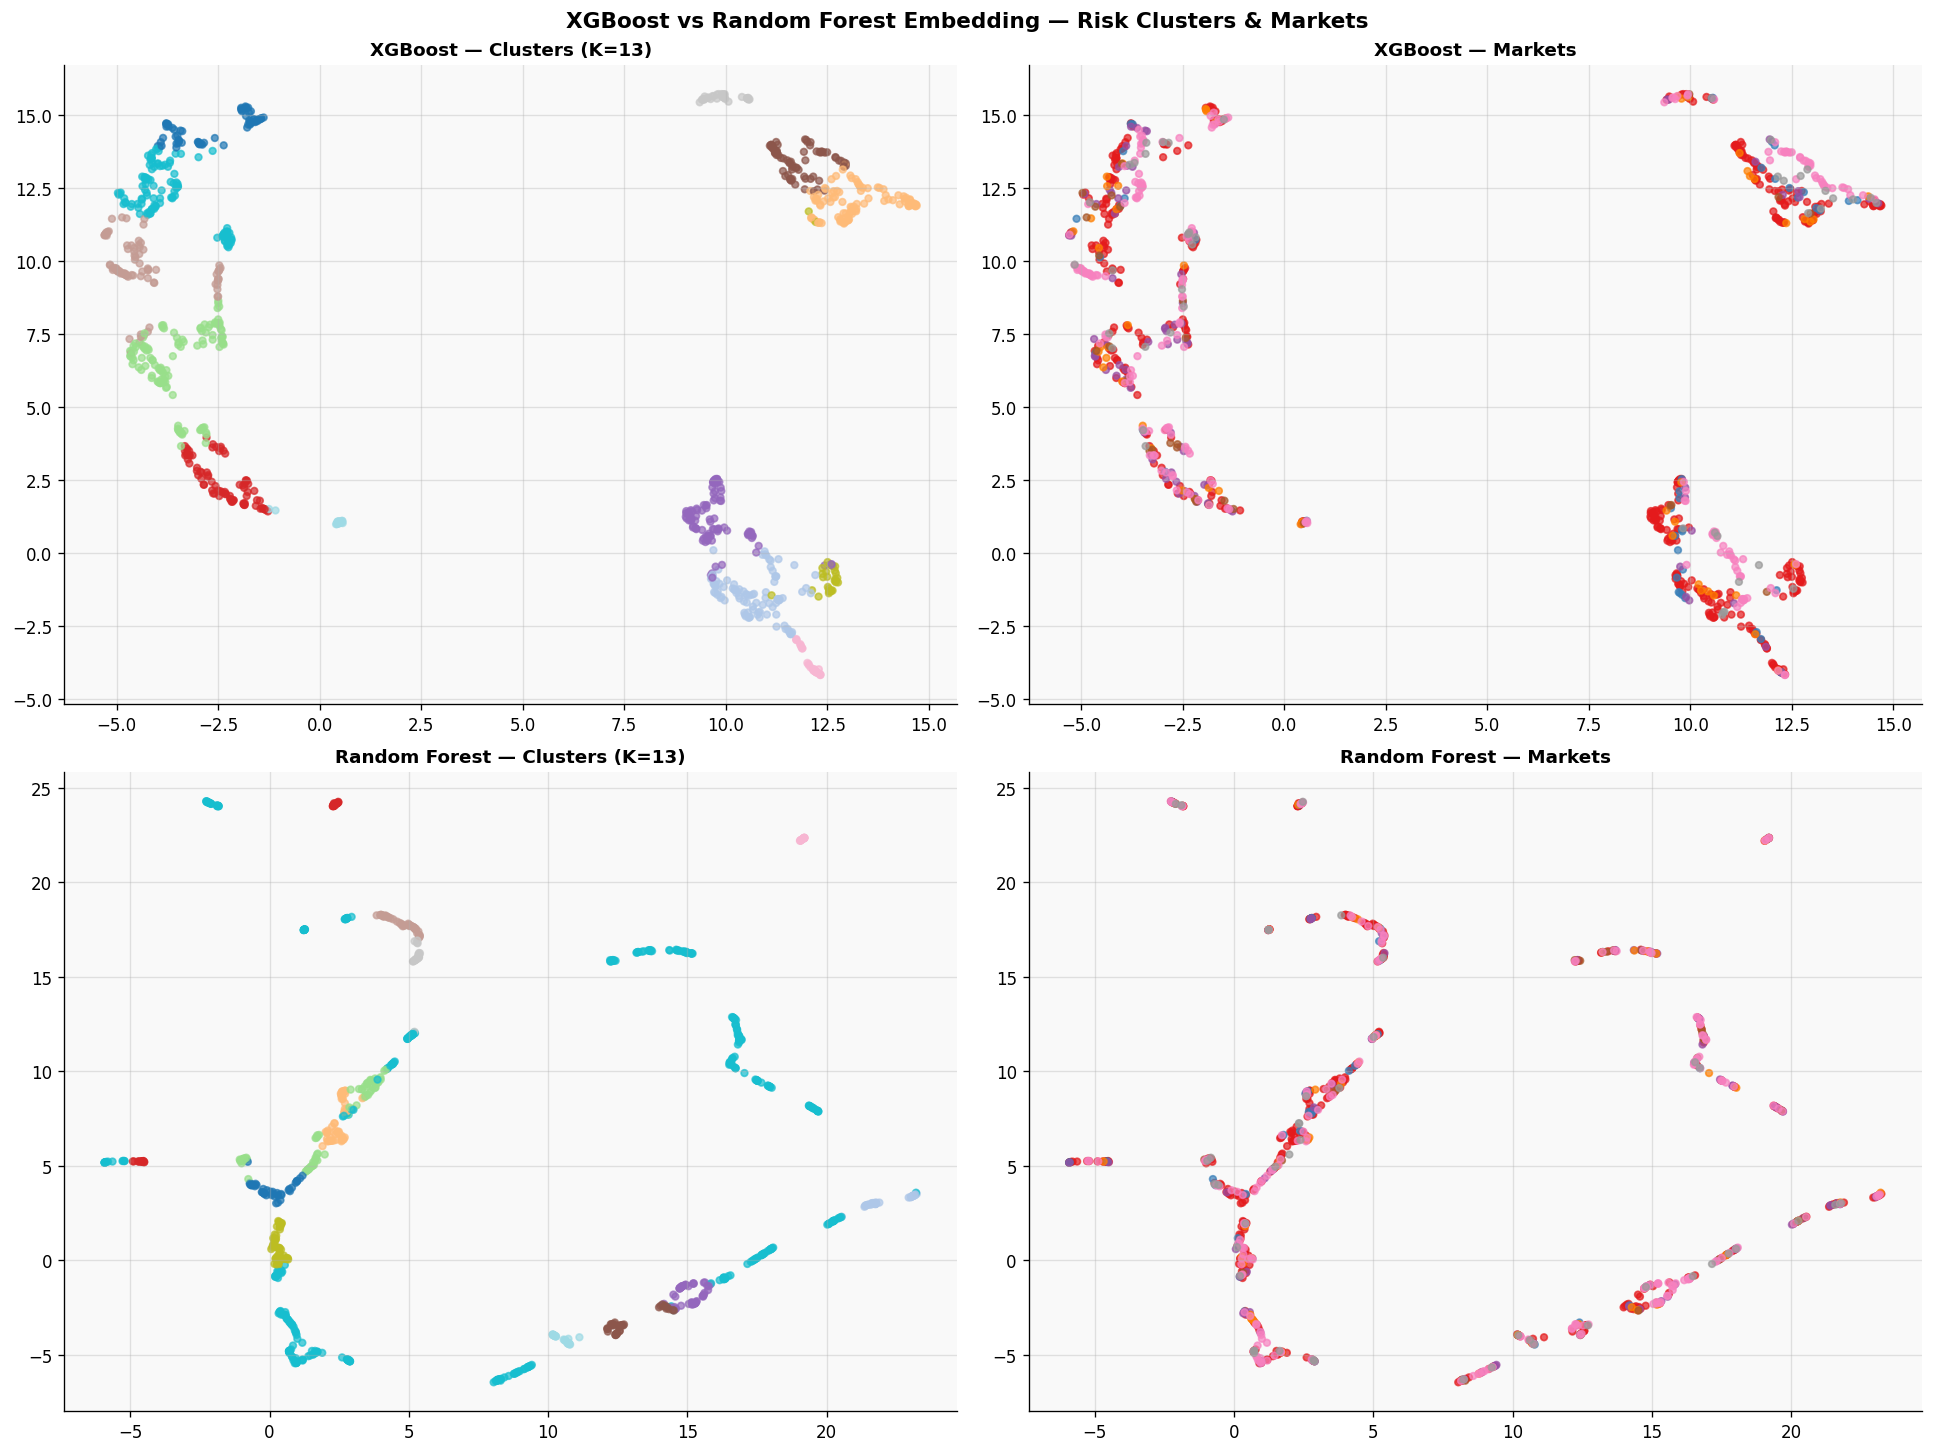

✅ Clustering complete


In [ ]:
# ── 2D visualisation ──────────────────────────────────────────────────────────
reducer = (umap.UMAP(n_components=2, random_state=42) if UMAP_OK
           else TSNE(n_components=2, random_state=42, perplexity=40))

print('Computing 2D embeddings (may take a few minutes)...')
X_2d_xgb = reducer.fit_transform(X_xgb_sc)
X_2d_rf  = reducer.fit_transform(X_rf_sc)

market_list  = list(feature_df['market'].unique())
market_codes = [market_list.index(m) for m in feature_df['market']]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
for row_idx, (X_2d, clusters, K, title_prefix) in enumerate([
    (X_2d_xgb, xgb_clusters, K_xgb, 'XGBoost'),
    (X_2d_rf,  rf_clusters,  K_rf,  'Random Forest'),
]):
    axes[row_idx, 0].scatter(X_2d[:, 0], X_2d[:, 1],
        c=clusters, cmap=plt.cm.get_cmap('tab20', K), s=16, alpha=0.7)
    axes[row_idx, 0].set_title(f'{title_prefix} — Clusters (K={K})', fontweight='bold')
    axes[row_idx, 1].scatter(X_2d[:, 0], X_2d[:, 1],
        c=market_codes,
        cmap=plt.cm.get_cmap('Set1', len(market_list)), s=16, alpha=0.7)
    axes[row_idx, 1].set_title(f'{title_prefix} — Markets', fontweight='bold')
fig.suptitle('XGBoost vs Random Forest Embedding — Risk Clusters & Markets',
             fontsize=13, fontweight='bold')
plt.savefig('cluster_2d_comparison.png', bbox_inches='tight'); plt.show()
print('✅ Clustering complete')

---
## Section 12 — Portfolio Construction
**Four strategies:**
- **G1:** Equal-Weight (benchmark)
- **G2:** GARCH-Copula Min-Variance
- **G3:** XGBoost Cluster HRP
- **G4:** Random Forest Cluster HRP

In [ ]:
port_ret_df = idx_daily.copy()
n_assets    = port_ret_df.shape[1]
mkts_list   = port_ret_df.columns.tolist()

def portfolio_performance(weights, returns_df, rf_daily=RF):
    w       = np.array(weights)
    r       = (returns_df @ w).dropna()
    ann_ret = r.mean() * 252
    ann_vol = r.std()  * np.sqrt(252)
    sharpe  = (ann_ret - rf_daily*252) / ann_vol if ann_vol > 0 else 0
    cum     = np.exp(r.cumsum())
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    var95   = np.percentile(r, 5)
    es95    = r[r <= var95].mean()
    return {'Ann. Return': ann_ret, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
            'Max DD': mdd, 'VaR 95%': var95, 'ES 95%': es95}

# ── G1: Equal-Weight ──────────────────────────────────────────────────────────
w_ew    = np.ones(n_assets) / n_assets
perf_ew = portfolio_performance(w_ew, port_ret_df)
print('G1 Equal-Weight:'); [print(f'  {k}: {v:.4f}') for k, v in perf_ew.items()]

G1 Equal-Weight:
  Ann. Return: 0.0913
  Ann. Vol: 0.1225
  Sharpe: 0.5825
  Max DD: -0.3560
  VaR 95%: -0.0108
  ES 95%: -0.0196


[None, None, None, None, None, None]

In [ ]:
# ── G2: GARCH-Copula Min-Variance ─────────────────────────────────────────────
def copula_min_variance(corr_matrix, vols_dict, mkts, max_w=0.40):
    vols = np.array([vols_dict[m] for m in mkts])
    R    = corr_matrix.loc[mkts, mkts].values
    Cov  = np.outer(vols, vols) * R
    def port_var(w): return w @ Cov @ w
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds      = [(0, max_w)] * len(mkts)
    res = minimize(port_var, np.ones(len(mkts))/len(mkts), method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 500})
    return res.x

garch_vols = {mkt: vol_df[mkt].mean() * np.sqrt(252) for mkt in mkts_list}
w_g2    = copula_min_variance(gaussian_corr, garch_vols, mkts_list)
perf_g2 = portfolio_performance(w_g2, port_ret_df)
print('G2 GARCH-Copula Min-Variance:')
[print(f'  {k}: {v:.4f}') for k, v in perf_g2.items()]
print(f'  Weights: {dict(zip(mkts_list, w_g2.round(3)))}')

# ── G3 & G4: Cluster HRP ──────────────────────────────────────────────────────
def cluster_hrp_weights(feature_df_col, mkts_list, port_ret_df, cluster_col):
    idx_cluster = {}
    for mkt in mkts_list:
        stocks = feature_df[feature_df['market'] == mkt]
        idx_cluster[mkt] = stocks[cluster_col].mode()[0] if len(stocks) > 0 else 0
    cluster_ids = sorted(set(idx_cluster.values()))
    n_clusters  = len(cluster_ids)
    w_hrp       = np.zeros(len(mkts_list))
    for c_id in cluster_ids:
        c_mkts  = [m for m in mkts_list if idx_cluster[m] == c_id]
        if not c_mkts: continue
        c_vols  = np.array([port_ret_df[m].std() for m in c_mkts])
        inv_vol = 1.0 / (c_vols + 1e-8)
        w_in    = inv_vol / inv_vol.sum()
        for mkt, wi in zip(c_mkts, w_in):
            w_hrp[mkts_list.index(mkt)] = wi / n_clusters
    return w_hrp / w_hrp.sum()

w_g3    = cluster_hrp_weights(feature_df, mkts_list, port_ret_df, 'cluster_xgb')
perf_g3 = portfolio_performance(w_g3, port_ret_df)
print('\nG3 XGBoost Cluster HRP:')
[print(f'  {k}: {v:.4f}') for k, v in perf_g3.items()]

w_g4    = cluster_hrp_weights(feature_df, mkts_list, port_ret_df, 'cluster_rf')
perf_g4 = portfolio_performance(w_g4, port_ret_df)
print('\nG4 Random Forest Cluster HRP:')
[print(f'  {k}: {v:.4f}') for k, v in perf_g4.items()]

G2 GARCH-Copula Min-Variance:
  Ann. Return: 0.0784
  Ann. Vol: 0.1067
  Sharpe: 0.5469
  Max DD: -0.3415
  VaR 95%: -0.0103
  ES 95%: -0.0170
  Weights: {'SP500': np.float64(0.179), 'EuroStoxx50': np.float64(0.0), 'FTSE100': np.float64(0.198), 'Ibovespa': np.float64(0.044), 'JSE40': np.float64(0.133), 'Nikkei225': np.float64(0.049), 'ASX50': np.float64(0.398)}

G3 XGBoost Cluster HRP:
  Ann. Return: 0.0894
  Ann. Vol: 0.1151
  Sharpe: 0.6032
  Max DD: -0.3459
  VaR 95%: -0.0108
  ES 95%: -0.0182

G4 Random Forest Cluster HRP:
  Ann. Return: 0.0880
  Ann. Vol: 0.1195
  Sharpe: 0.5691
  Max DD: -0.3521
  VaR 95%: -0.0108
  ES 95%: -0.0192


[None, None, None, None, None, None]

=== PORTFOLIO COMPARISON ===


,Ann. Return,Ann. Vol,Sharpe,Max DD,VaR 95%,ES 95%
G1 Equal-Weight,0.0913,0.1225,0.5825,-0.3560,-0.0108,-0.0196
G2 Copula Min-Var,0.0784,0.1067,0.5469,-0.3415,-0.0103,-0.0170
G3 XGBoost HRP,0.0894,0.1151,0.6032,-0.3459,-0.0108,-0.0182
G4 Random Forest HRP,0.0880,0.1195,0.5691,-0.3521,-0.0108,-0.0192


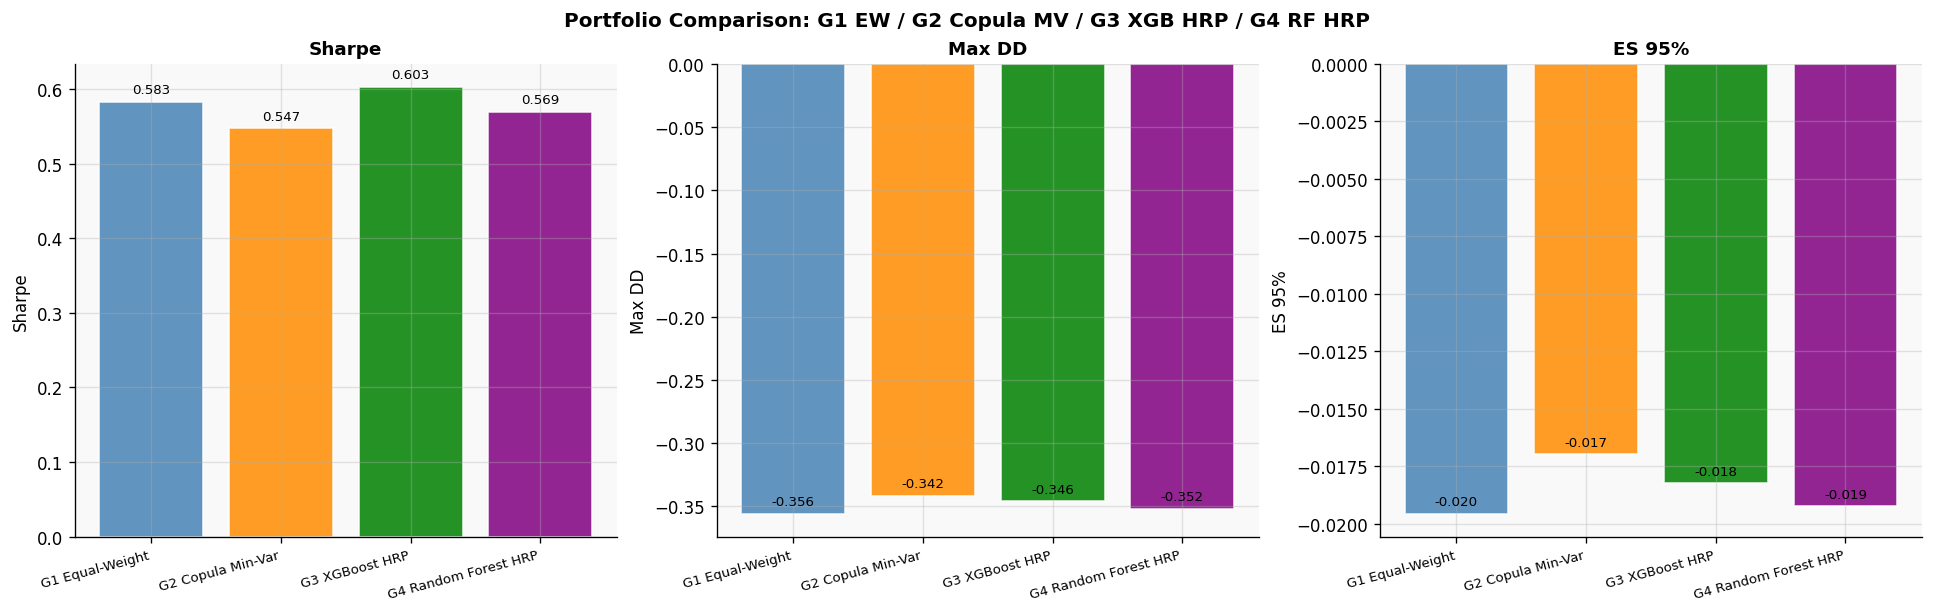

In [ ]:
# ── Portfolio Comparison Summary ──────────────────────────────────────────────
summary_df = pd.DataFrame({
    'G1 Equal-Weight':      perf_ew,
    'G2 Copula Min-Var':    perf_g2,
    'G3 XGBoost HRP':       perf_g3,
    'G4 Random Forest HRP': perf_g4,
}).T
print('=== PORTFOLIO COMPARISON ===')
display(summary_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
COLORS = ['steelblue', 'darkorange', 'green', 'purple']
for ax, metric in zip(axes, ['Sharpe', 'Max DD', 'ES 95%']):
    vals = summary_df[metric]
    ax.bar(vals.index, vals, color=COLORS, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold'); ax.set_ylabel(metric)
    ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v + abs(v)*0.02, f'{v:.3f}', ha='center', fontsize=8)
fig.suptitle('Portfolio Comparison: G1 EW / G2 Copula MV / G3 XGB HRP / G4 RF HRP',
             fontsize=12, fontweight='bold')
plt.savefig('portfolio_comparison.png', bbox_inches='tight'); plt.show()

---
## Section 13 — Horizon Performance (D1–D5, W1–W4)

Sharpe Ratio by Horizon:


,EW,Copula MV,XGB HRP,RF HRP
D1,0.583,0.547,0.603,0.569
D2,0.864,0.818,0.879,0.844
D3,1.023,0.967,1.036,1.000
D4,1.169,1.098,1.177,1.143
D5,1.295,1.213,1.300,1.265
W1,0.588,0.551,0.591,0.575
W2,0.822,0.756,0.825,0.802
W3,0.995,0.908,1.000,0.970
W4,1.146,1.039,1.153,1.116


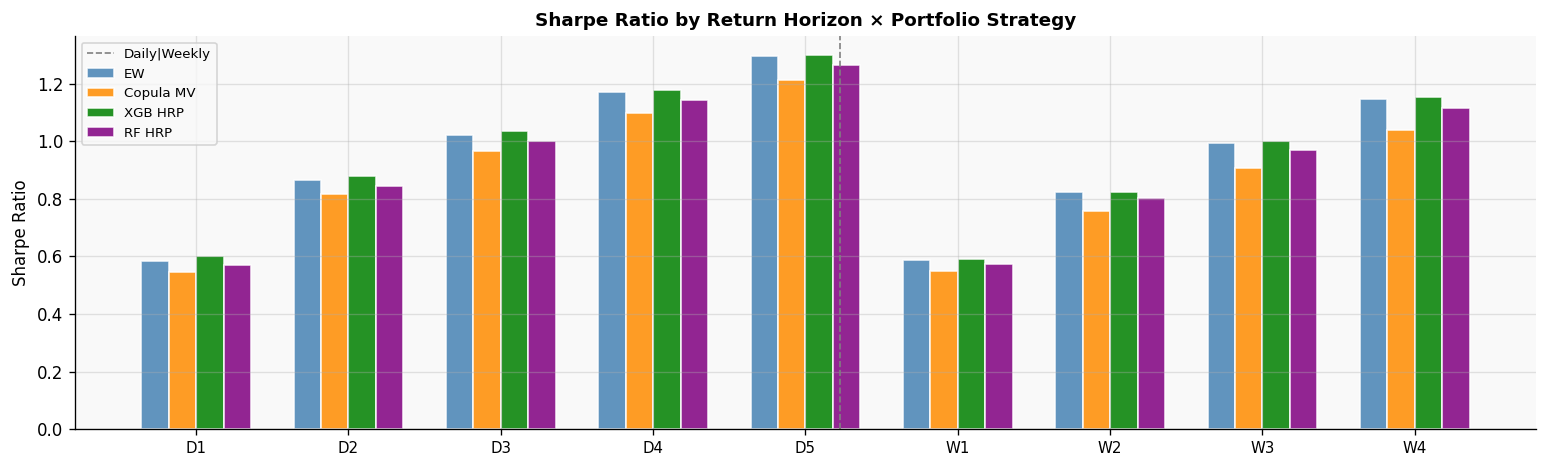

In [ ]:
horizon_results = {}

for h_label, ret_df in horizon_returns.items():
    ret_df = ret_df.dropna()
    results_h = {}
    for port_name, w in [('EW', w_ew), ('Copula MV', w_g2),
                          ('XGB HRP', w_g3), ('RF HRP', w_g4)]:
        r       = (ret_df @ w).dropna()
        ann_fac = 252 if 'D' in h_label else 52
        ann_ret = r.mean() * ann_fac
        ann_vol = r.std()  * np.sqrt(ann_fac)
        sharpe  = (ann_ret - RF * ann_fac) / ann_vol if ann_vol > 0 else 0
        cum     = np.exp(r.cumsum())
        mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
        results_h[port_name] = {'Ann.Return': ann_ret, 'Ann.Vol': ann_vol,
                                  'Sharpe': sharpe, 'MaxDD': mdd}
    horizon_results[h_label] = results_h

sharpe_tbl = pd.DataFrame({
    h: {p: horizon_results[h][p]['Sharpe'] for p in ['EW','Copula MV','XGB HRP','RF HRP']}
    for h in all_labels
}).T
print('Sharpe Ratio by Horizon:')
display(sharpe_tbl.round(3))

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(all_labels)); w_bar = 0.18
colors_p = ['steelblue', 'darkorange', 'green', 'purple']
for i, (p_name, col) in enumerate(zip(['EW','Copula MV','XGB HRP','RF HRP'], colors_p)):
    vals = [horizon_results[h][p_name]['Sharpe'] for h in all_labels]
    ax.bar(x + i*w_bar, vals, w_bar, label=p_name, color=col, alpha=0.85, edgecolor='white')
ax.set_xticks(x + 1.5*w_bar); ax.set_xticklabels(all_labels, fontsize=9)
ax.axvline(len(DAILY_HORIZONS) - 0.5, color='grey', ls='--', lw=1, label='Daily|Weekly')
ax.set_ylabel('Sharpe Ratio'); ax.legend(fontsize=8)
ax.set_title('Sharpe Ratio by Return Horizon × Portfolio Strategy', fontweight='bold')
plt.tight_layout(); plt.savefig('horizon_sharpe.png', bbox_inches='tight'); plt.show()

---
## Section 14 — Copula Monte Carlo VaR / ES

In [ ]:
def pit_to_ret(u_col, hist_series):
    return np.quantile(hist_series.dropna(), np.clip(u_col, 0.001, 0.999))

portfolios_for_mc = {
    'G1 EW':        w_ew,
    'G2 Copula MV': w_g2,
    'G3 XGB HRP':   w_g3,
    'G4 RF HRP':    w_g4,
}

print('Running Monte Carlo simulation (N=10,000)...')
sim_full = gc_full.sample(10_000)
mc_results = {}

for port_name, w in portfolios_for_mc.items():
    sim_eq = np.column_stack([
        pit_to_ret(sim_full[c].values, idx_daily[c]) for c in EQUITY_COLS
    ])
    port_sim = sim_eq @ w
    var95 = np.percentile(port_sim, 5)
    es95  = port_sim[port_sim <= var95].mean()
    var99 = np.percentile(port_sim, 1)
    es99  = port_sim[port_sim <= var99].mean()
    mc_results[port_name] = {
        'VaR 95%': var95*100, 'ES 95%': es95*100,
        'VaR 99%': var99*100, 'ES 99%': es99*100,
    }
    print(f'  {port_name}: VaR95={var95*100:.3f}%  ES95={es95*100:.3f}%  '
          f'VaR99={var99*100:.3f}%  ES99={es99*100:.3f}%')

mc_df = pd.DataFrame(mc_results).T
print('\n── Monte Carlo Risk Summary ──')
display(mc_df.round(3))

Running Monte Carlo simulation (N=10,000)...
  G1 EW: VaR95=-1.122%  ES95=-1.595%  VaR99=-1.861%  ES99=-2.303%
  G2 Copula MV: VaR95=-1.031%  ES95=-1.459%  VaR99=-1.746%  ES99=-2.157%
  G3 XGB HRP: VaR95=-1.083%  ES95=-1.493%  VaR99=-1.754%  ES99=-2.131%
  G4 RF HRP: VaR95=-1.098%  ES95=-1.560%  VaR99=-1.831%  ES99=-2.265%

── Monte Carlo Risk Summary ──


,VaR 95%,ES 95%,VaR 99%,ES 99%
G1 EW,-1.122,-1.595,-1.861,-2.303
G2 Copula MV,-1.031,-1.459,-1.746,-2.157
G3 XGB HRP,-1.083,-1.493,-1.754,-2.131
G4 RF HRP,-1.098,-1.560,-1.831,-2.265


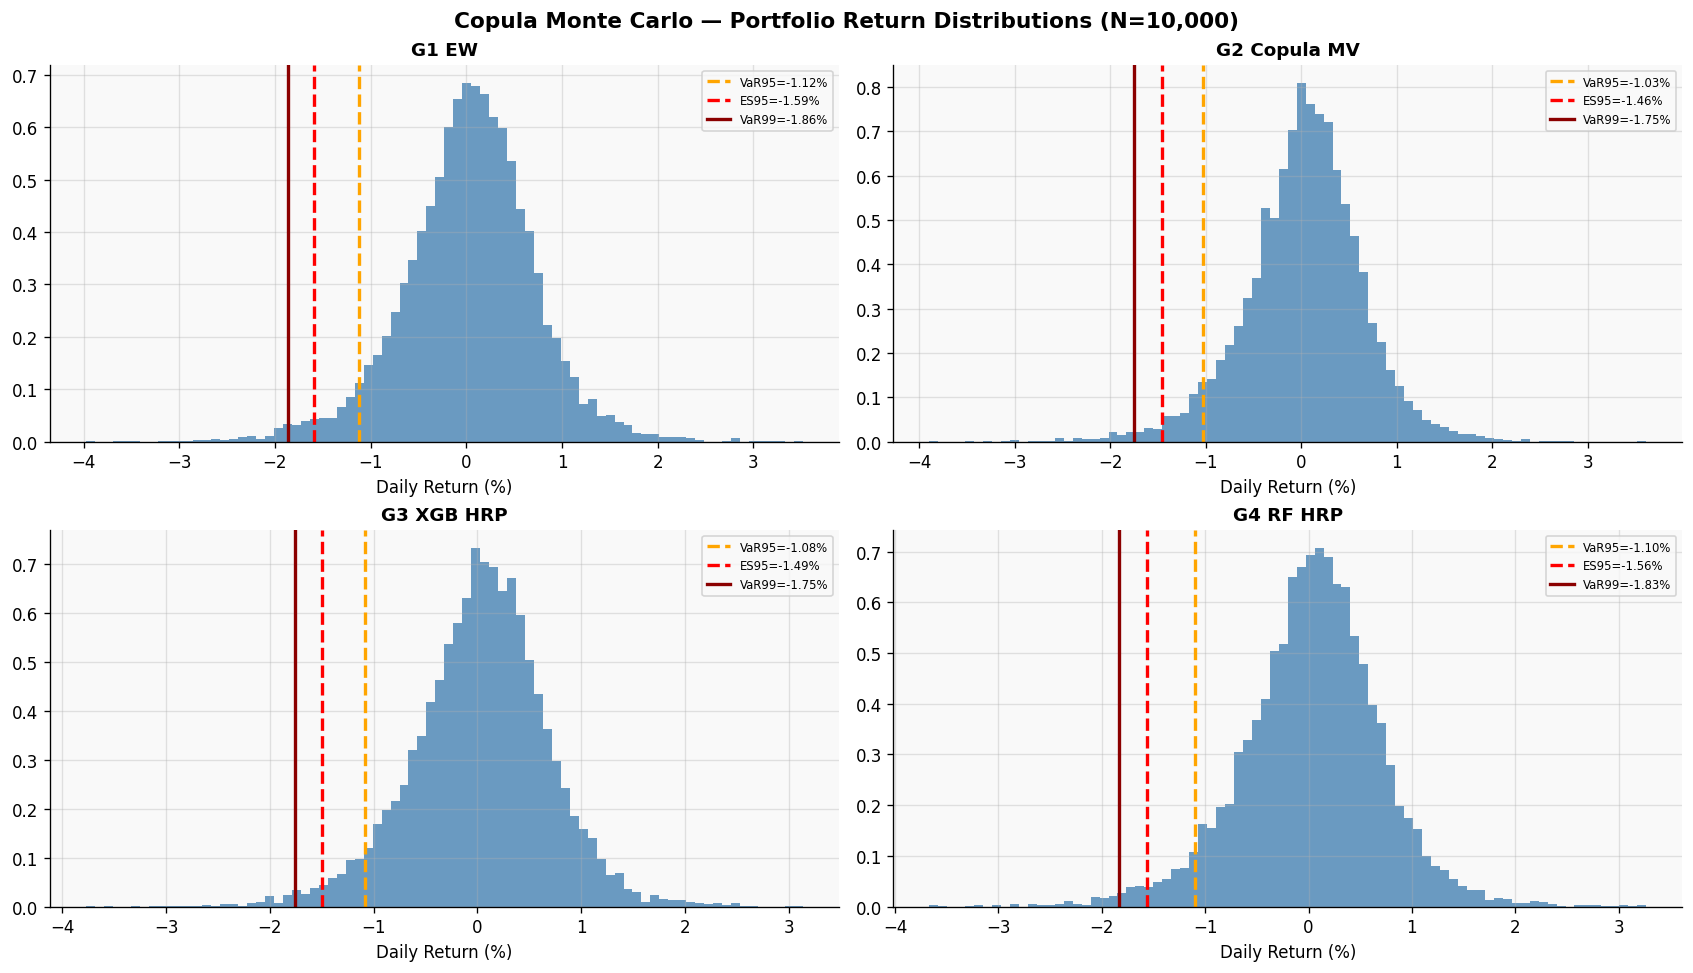

In [ ]:
# ── Portfolio return distribution plots ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
for ax, (port_name, w) in zip(axes.flatten(), portfolios_for_mc.items()):
    sim_eq   = np.column_stack([pit_to_ret(sim_full[c].values, idx_daily[c])
                                 for c in EQUITY_COLS])
    port_sim = sim_eq @ w * 100
    ax.hist(port_sim, bins=80, density=True, color='steelblue', alpha=0.8)
    v95 = np.percentile(port_sim, 5)
    e95 = port_sim[port_sim <= v95].mean()
    v99 = np.percentile(port_sim, 1)
    ax.axvline(v95, color='orange',  lw=2, ls='--', label=f'VaR95={v95:.2f}%')
    ax.axvline(e95, color='red',     lw=2, ls='--', label=f'ES95={e95:.2f}%')
    ax.axvline(v99, color='darkred', lw=2,           label=f'VaR99={v99:.2f}%')
    ax.set_title(port_name, fontweight='bold')
    ax.set_xlabel('Daily Return (%)'); ax.legend(fontsize=7)
fig.suptitle('Copula Monte Carlo — Portfolio Return Distributions (N=10,000)',
             fontsize=13, fontweight='bold')
plt.savefig('copula_var_es.png', bbox_inches='tight'); plt.show()

---
## Section 15 — Transaction Cost Sensitivity

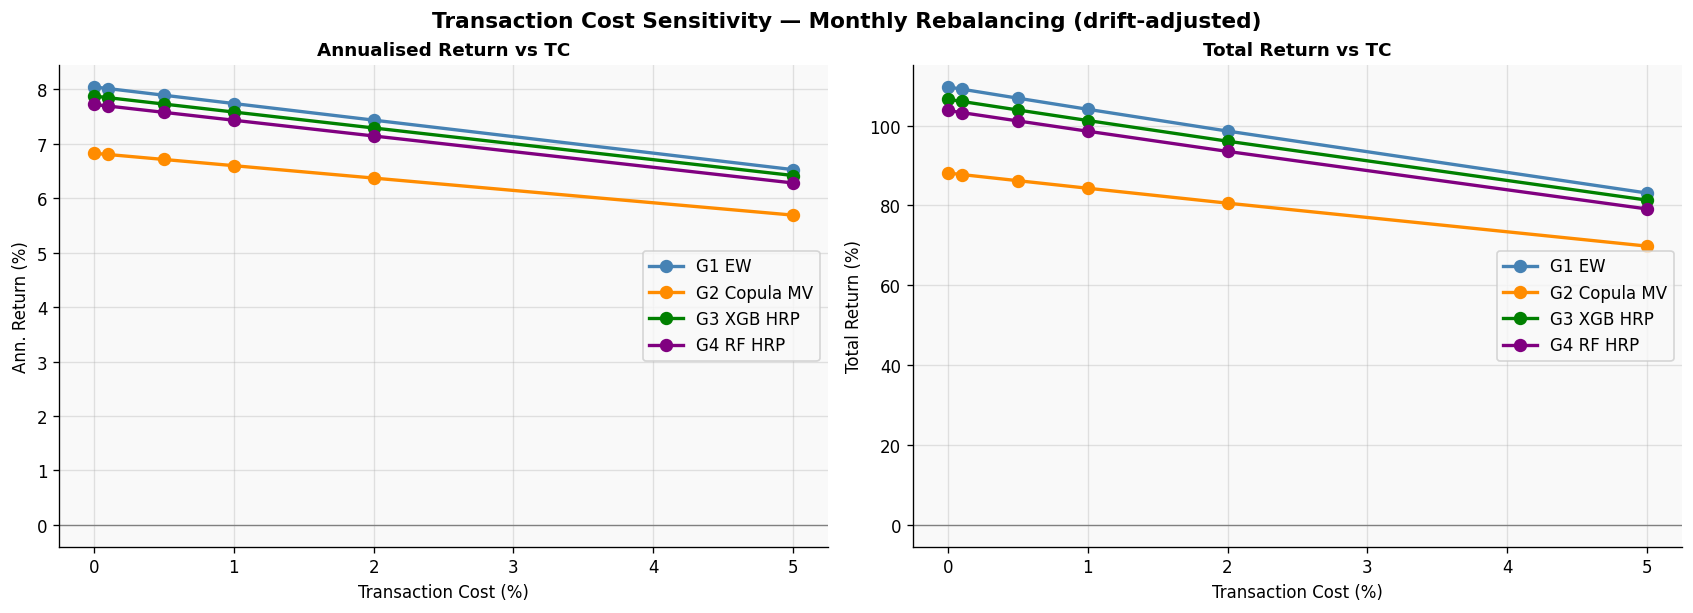


=== TC IMPACT (Annualised Return %) ===


,0.0%,0.1%,0.5%,1.0%,2.0%,5.0%
Portfolio,,,,,,
G1 EW,8.05,8.02,7.89,7.74,7.44,6.53
G2 Copula MV,6.83,6.80,6.71,6.60,6.37,5.69
G3 XGB HRP,7.88,7.85,7.73,7.59,7.29,6.42
G4 RF HRP,7.72,7.70,7.58,7.43,7.15,6.28


In [ ]:
TC_LEVELS  = [0.000, 0.001, 0.005, 0.010, 0.020, 0.050]
REBAL_FREQ = 21  # monthly

def apply_tc(returns_df, target_w, tc, rebal_freq=21):
    r        = returns_df.values
    w_cur    = target_w.copy()
    port_val = 1.0
    cum_rets = []
    for t in range(len(r)):
        daily    = (w_cur * r[t]).sum()
        port_val *= (1.0 + daily)
        w_cur    = w_cur * (1.0 + r[t])
        w_sum    = w_cur.sum()
        if w_sum > 0: w_cur /= w_sum
        cum_rets.append(port_val)
        if (t + 1) % rebal_freq == 0:
            turnover  = np.abs(w_cur - target_w).sum()
            port_val -= tc * turnover * port_val
            w_cur     = target_w.copy()
    return pd.Series(cum_rets, index=returns_df.index)

tc_results = {}
for p_name, w in portfolios_for_mc.items():
    for tc in TC_LEVELS:
        cum       = apply_tc(port_ret_df, w, tc)
        ann_ret   = cum.iloc[-1]**(252/len(cum)) - 1
        total_ret = cum.iloc[-1] - 1
        tc_results[(p_name, tc)] = {'Ann. Return': ann_ret, 'Total Return': total_ret}

tc_df = pd.DataFrame(tc_results).T
tc_df.index = pd.MultiIndex.from_tuples(tc_df.index, names=['Portfolio','TC'])
tc_df = tc_df.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for p_name, col in zip(portfolios_for_mc.keys(), ['steelblue','darkorange','green','purple']):
    sub = tc_df.loc[p_name]
    axes[0].plot([t*100 for t in TC_LEVELS], sub['Ann. Return']*100,
                 'o-', color=col, label=p_name, lw=2, ms=7)
    axes[1].plot([t*100 for t in TC_LEVELS], sub['Total Return']*100,
                 'o-', color=col, label=p_name, lw=2, ms=7)
for ax, title, ylabel in zip(axes,
    ['Annualised Return vs TC','Total Return vs TC'],
    ['Ann. Return (%)','Total Return (%)']):
    ax.set_xlabel('Transaction Cost (%)'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.axhline(0, color='grey', lw=0.8)
fig.suptitle('Transaction Cost Sensitivity — Monthly Rebalancing (drift-adjusted)',
             fontsize=13, fontweight='bold')
plt.savefig('transaction_costs.png', bbox_inches='tight'); plt.show()

pivot = tc_df['Ann. Return'].unstack(level='TC') * 100
pivot.columns = [f'{c*100:.1f}%' for c in pivot.columns]
print('\n=== TC IMPACT (Annualised Return %) ===')
display(pivot.round(2))

---
## Section 16 — Export All Results & Download
> All CSVs and plots are saved to `/content/`. Run the cell below to download a ZIP of everything.

In [ ]:
import zipfile, os

# ── Save CSVs ────────────────────────────────────────────────────────────────
exports = {
    'garch_index_params.csv':           garch_params_idx,
    'copula_full_correlation.csv':      gaussian_corr_full,
    'macro_equity_copula_corr.csv':     macro_eq_corr,
    'ml_model_comparison.csv':          ml_compare,
    'stock_clusters.csv':               feature_df[['market','cluster_xgb','cluster_rf'] + NUMERIC_FEATURES],
    'portfolio_summary.csv':            summary_df,
    'horizon_sharpe.csv':               sharpe_tbl,
    'copula_mc_risk.csv':               mc_df,
    'transaction_cost_sensitivity.csv': tc_df,
}

for fname, df in exports.items():
    df.to_csv(f'/content/{fname}')
    print(f'✅ {fname}')

# Horizon copula correlations
for h_lbl, df in horizon_copula_corr.items():
    df.to_csv(f'/content/copula_corr_{h_lbl}.csv')
print(f'✅ copula_corr_D1–D5, W1–W4 ({len(horizon_copula_corr)} files)')

# ── Bundle everything into a ZIP ──────────────────────────────────────────────
zip_path = '/content/garch_copula_results.zip'
png_files = [f for f in os.listdir('/content') if f.endswith('.png')]
csv_files = [f for f in os.listdir('/content') if f.endswith('.csv') and not f.startswith('streamlined')]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in png_files + csv_files:
        zf.write(f'/content/{fname}', fname)

print(f'\n📦 Archive created: {zip_path}')
print(f'   Contains {len(png_files)} plots + {len(csv_files)} CSV files')

✅ garch_index_params.csv
✅ copula_full_correlation.csv
✅ macro_equity_copula_corr.csv
✅ ml_model_comparison.csv
✅ stock_clusters.csv
✅ portfolio_summary.csv
✅ horizon_sharpe.csv
✅ copula_mc_risk.csv
✅ transaction_cost_sensitivity.csv
✅ copula_corr_D1–D5, W1–W4 (9 files)

📦 Archive created: /content/garch_copula_results.zip
   Contains 13 plots + 18 CSV files


In [ ]:
# ── Download the ZIP ──────────────────────────────────────────────────────────
from google.colab import files
files.download('/content/garch_copula_results.zip')
print('✅ Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


---
## 🎉 Pipeline Complete!

**Outputs generated:**

| File | Description |
|---|---|
| `garch_index_params.csv` | GARCH(1,1) parameters for all indices |
| `copula_full_correlation.csv` | Full equity+macro Gaussian copula matrix |
| `macro_equity_copula_corr.csv` | Macro → equity copula correlations |
| `copula_corr_D1.csv … W4.csv` | Horizon-specific copula correlations |
| `ml_model_comparison.csv` | XGBoost vs RF model performance |
| `stock_clusters.csv` | All stocks with cluster labels + features |
| `portfolio_summary.csv` | G1–G4 performance metrics |
| `horizon_sharpe.csv` | Sharpe ratios across all horizons |
| `copula_mc_risk.csv` | Monte Carlo VaR/ES estimates |
| `transaction_cost_sensitivity.csv` | TC impact on returns |
| `*.png` | All charts and visualisations |